# Lecture 1: Social Network Analysis, Learning, and Data Collection

Welcome to the first code notebook of the **#SMWA** course!  

In this notebook, we'll begin exploring how social networks are represented, analyzed, and used to make predictions. We'll also learn how social media data can be collected. This notebook will guide you through hands-on examples, visualizations, and foundational concepts that we’ll build on throughout the course.

This notebook covers three main topics:

1. **Social Network Analysis**  
   Learn to calculate several network metrics, visualize graphs, detect communities, and more!

2. **Social Network Learning**  
   Apply relational neighbor classifiers to predict node attributes based on network neighbors.

3. **Data Collection**  
   Learn web scraping with BeautifulSoup, collect data from open platforms, and explore approaches for more restricted platforms.

For additional background and deeper explanations, consult:

- [NetworkX Documentation](https://networkx.org/documentation/stable/)
- Easley, D., & Kleinberg, J. (2010). *Networks, Crowds, and Markets: Reasoning about a Highly Connected World*. Cambridge University Press. ([link](https://www.cs.cornell.edu/home/kleinber/networks-book/networks-book.pdf))
- Barabási, A. L. (2016). *Network Science*. Cambridge University Press. ([link](https://networksciencebook.com/))


## Social Network Analysis


### Network Packages in Python

To perform network analysis in Python, we will primarily use the `NetworkX` package. 

`NetworkX` is a comprehensive library for creating, manipulating, and analyzing complex networks. It provides implementations for many of the algorithms we will encounter in this notebook, including centrality measures, shortest-path computations, and community detection.

Before starting the exercises, make sure the required packages are installed and imported. This should normally be the case if you have followed the installation guide. 

In [1]:
# Import required packages for network analysis
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['figure.dpi'] = 100

# Check networkx version
print(f"NetworkX version: {nx.__version__}")

NetworkX version: 3.6



Throughout the notebooks, we'll use `NetworkX` as the primary package for network analysis, along with `pandas` for data manipulation and `matplotlib/seaborn` for visualization.

### Network Basics: Size and Structure

#### Network Size Analysis

In this section, we'll explore fundamental characteristics of social networks using the **Moreno dataset**. Understanding network size, i.e., the number of nodes (vertices) and connections (edges), is the foundation of network analysis.

##### Loading the Dataset

We'll load the Moreno dataset from our Data folder. The Moreno network represents social relationships among students, with gender attributes for each node.

In [4]:
# Load the Moreno network from CSV files

# Read the edgelist
moreno_edges = pd.read_csv("Data/Moreno_edgelist.csv")
moreno_vertices = pd.read_csv("Data/Moreno_nodes.csv")

# Create a NetworkX graph from the edgelist
G_moreno = nx.from_pandas_edgelist(
    moreno_edges, 
    source='source', 
    target='target',
    create_using=nx.Graph()  # Undirected graph
)

# Add gender attributes to nodes
gender_dict = dict(zip(moreno_vertices['vertex_id'], moreno_vertices['gender']))
nx.set_node_attributes(G_moreno, gender_dict, 'gender')

print(f"Moreno network loaded successfully")

Moreno network loaded successfully


##### Visualizing the Network

Let's visualize the network to understand its structure. We'll color nodes by gender to highlight potential patterns in social connections.

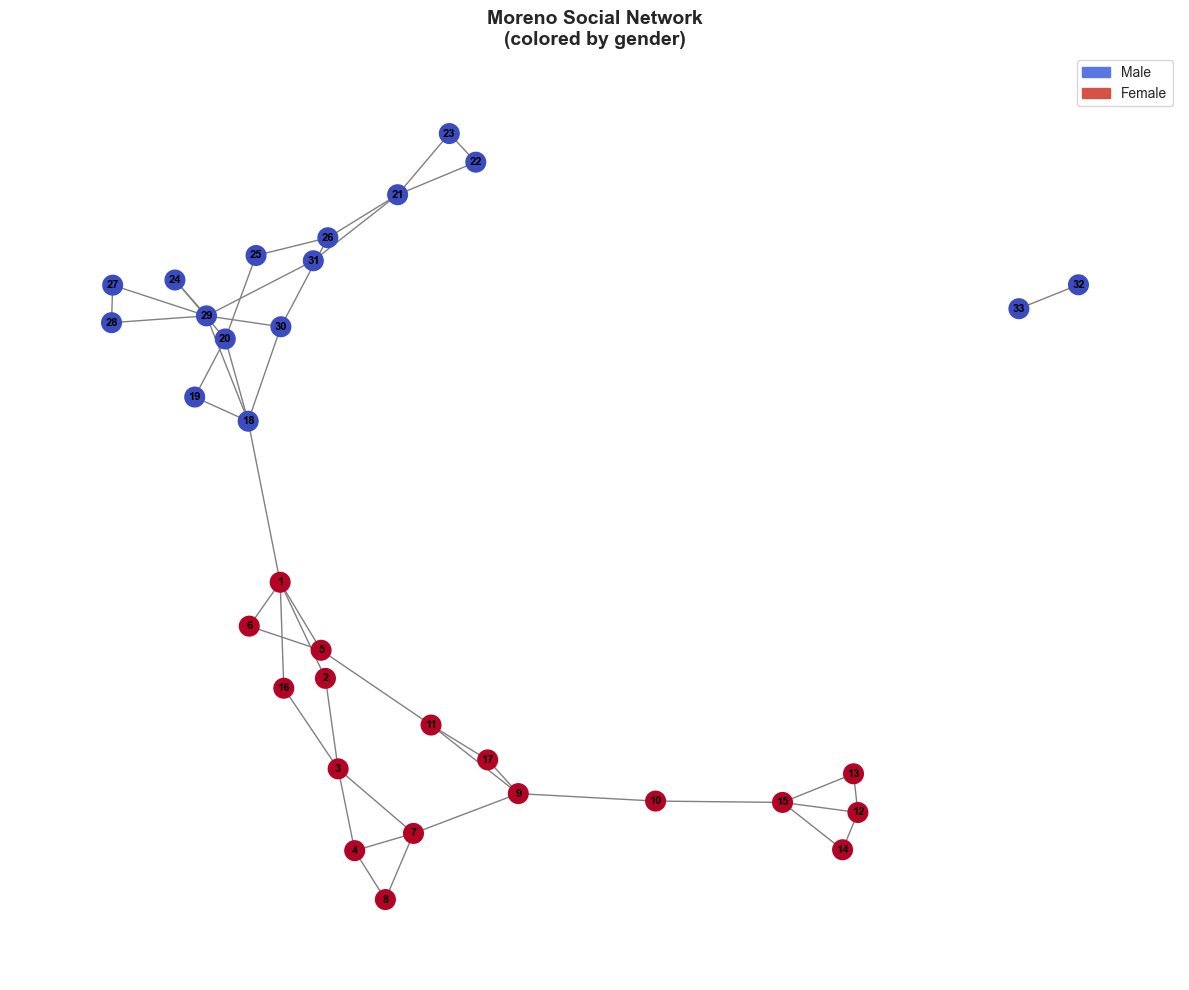

In [5]:
# Create a visualization colored by gender
fig, ax = plt.subplots(figsize=(12, 10))

# Get gender attribute for each node
node_colors = [G_moreno.nodes[node].get('gender', 0) for node in G_moreno.nodes()]

# Create layout (spring layout creates a force-directed visualization)
pos = nx.spring_layout(G_moreno, seed=42)

# Draw the network
nx.draw_networkx(
    G_moreno,
    pos,
    node_color=node_colors,
    cmap='coolwarm',
    node_size=200,
    with_labels=True,
    font_size=8,
    font_weight='bold',
    edge_color='gray',
    ax=ax
)

# Add legend
legend_elements = [
    mpatches.Patch(color=plt.cm.coolwarm(0.1), label="Male"),
    mpatches.Patch(color=plt.cm.coolwarm(0.9), label="Female")
]
ax.legend(handles=legend_elements)

ax.set_title("Moreno Social Network\n(colored by gender)", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

**Note:** Don't worry if you don't understand every detail of the visualization code yet. The specifics will become clearer as we progress through the exercises. For now, focus on understanding what the network represents.

##### Network Size

The **size** of a network refers to the number of nodes (vertices). In NetworkX, we use `number_of_nodes()` or simply `len()` to get this information:

In [6]:
# Get the number of nodes in the network
n_nodes = G_moreno.number_of_nodes()
print(f"Network size (number of nodes): {n_nodes}")

Network size (number of nodes): 33


##### Number of Edges

The number of **edges** (connections) tells us how many relationships exist in the network. We use `number_of_edges()` for this:

In [7]:
# Get the number of edges in the network
n_edges = G_moreno.number_of_edges()
print(f"Number of edges: {n_edges}")

Number of edges: 46


##### Additional Network Information

For a detailed overview of the network structure, we can access various graph properties directly. `NetworkX` provides attributes and methods to examine nodes, edges, and network statistics:

In [8]:
# Display comprehensive network information
print("Network Attributes:")
print("=" * 40)
print(f"Number of nodes: {G_moreno.number_of_nodes()}")
print(f"Directed: {G_moreno.is_directed()}")
print(f"Multigraph: {G_moreno.is_multigraph()}")

# Edge information
n_nodes = G_moreno.number_of_nodes()
n_edges = G_moreno.number_of_edges()
max_edges = n_nodes * (n_nodes - 1) / 2  # For undirected graph
missing_edges = int(max_edges - n_edges)

print(f"\nTotal edges: {n_edges}")
print(f"Missing edges: {missing_edges}")
print(f"Non-missing edges: {n_edges}")

# Calculate and display density
density = nx.density(G_moreno)
print(f"Density: {density:.8f}")

# Node attributes summary
print("\nNode Attributes:")
print("=" * 40)

# Gender attribute statistics
genders = [G_moreno.nodes[node].get('gender', 0) for node in G_moreno.nodes()]
gender_series = pd.Series(genders)
print("Gender (numeric attribute):")
print(f"  Min: {gender_series.min():.1f}")
print(f"  1st Qu: {gender_series.quantile(0.25):.1f}")
print(f"  Median: {gender_series.median():.1f}")
print(f"  Mean: {gender_series.mean():.3f}")
print(f"  3rd Qu: {gender_series.quantile(0.75):.1f}")
print(f"  Max: {gender_series.max():.1f}")

# Node names
print(f"\nVertex names: {n_nodes} valid vertex names")

# Check for edge attributes
if len(G_moreno.edges()) > 0:
    edge_attrs = list(list(G_moreno.edges(data=True))[0][2].keys())
    if edge_attrs:
        print(f"\nEdge attributes: {', '.join(edge_attrs)}")
    else:
        print("\nNo edge attributes")
else:
    print("\nNo edge attributes")

Network Attributes:
Number of nodes: 33
Directed: False
Multigraph: False

Total edges: 46
Missing edges: 482
Non-missing edges: 46
Density: 0.08712121

Node Attributes:
Gender (numeric attribute):
  Min: 1.0
  1st Qu: 1.0
  Median: 2.0
  Mean: 1.515
  3rd Qu: 2.0
  Max: 2.0

Vertex names: 33 valid vertex names

No edge attributes


#### Network Density and Components

In this section, we'll explore two important network properties: **density** and **components**. These metrics help us understand how interconnected a network is and identify distinct subgroups within it.

##### Network Density

**Network density** measures the proportion of actual connections in a network compared to the maximum possible number of connections. It ranges from 0 (no connections) to 1 (all possible connections exist).

The formula differs depending on whether the graph is directed or undirected:

**For undirected graphs** (e.g., Facebook friendships, group assignments):
$$\text{Density} = \frac{2L}{K(K-1)}$$

**For directed graphs** (e.g., Twitter follows):
$$\text{Density} = \frac{L}{K(K-1)}$$

where:
- $L$ = number of edges (ties/links) in the network
- $K$ = number of nodes (vertices) in the network

A higher density indicates a more interconnected network.

In [10]:
# Calculate network density for the Moreno network
density = nx.density(G_moreno)
print(f"Moreno network density: {density:.4f}")
print(f"\nInterpretation: {density*100:.2f}% of all possible connections exist")

Moreno network density: 0.0871

Interpretation: 8.71% of all possible connections exist


##### Network Components

A **component** is a subset of nodes where every node is connected to every other node through some path (directly or indirectly). Identifying components helps us understand the overall structure and connectivity of the network.

In an **undirected graph**, we look for **connected components**. A network may consist of:
- One large component (a fully connected network)
- Multiple components (disconnected subgroups)

In [11]:
# Find the number of connected components
n_components = nx.number_connected_components(G_moreno)
print(f"Number of components: {n_components}")

# Get detailed information about each component
components = list(nx.connected_components(G_moreno))

print(f"\nComponent details:")
for i, component in enumerate(components, 1):
    print(f"  Component {i}: {len(component)} nodes")

# Get component membership for each node
component_membership = {}
for comp_id, component in enumerate(components, 1):
    for node in component:
        component_membership[node] = comp_id

# Display membership for first 10 nodes
print(f"\nNode-to-component mapping (first 10 nodes):")
for node in list(G_moreno.nodes())[:10]:
    print(f"  Node {node}: Component {component_membership[node]}")

Number of components: 2

Component details:
  Component 1: 31 nodes
  Component 2: 2 nodes

Node-to-component mapping (first 10 nodes):
  Node 1: Component 1
  Node 2: Component 1
  Node 5: Component 1
  Node 18: Component 1
  Node 6: Component 1
  Node 16: Component 1
  Node 3: Component 1
  Node 4: Component 1
  Node 7: Component 1
  Node 8: Component 1


Let's visualize the network with nodes colored by their component membership:

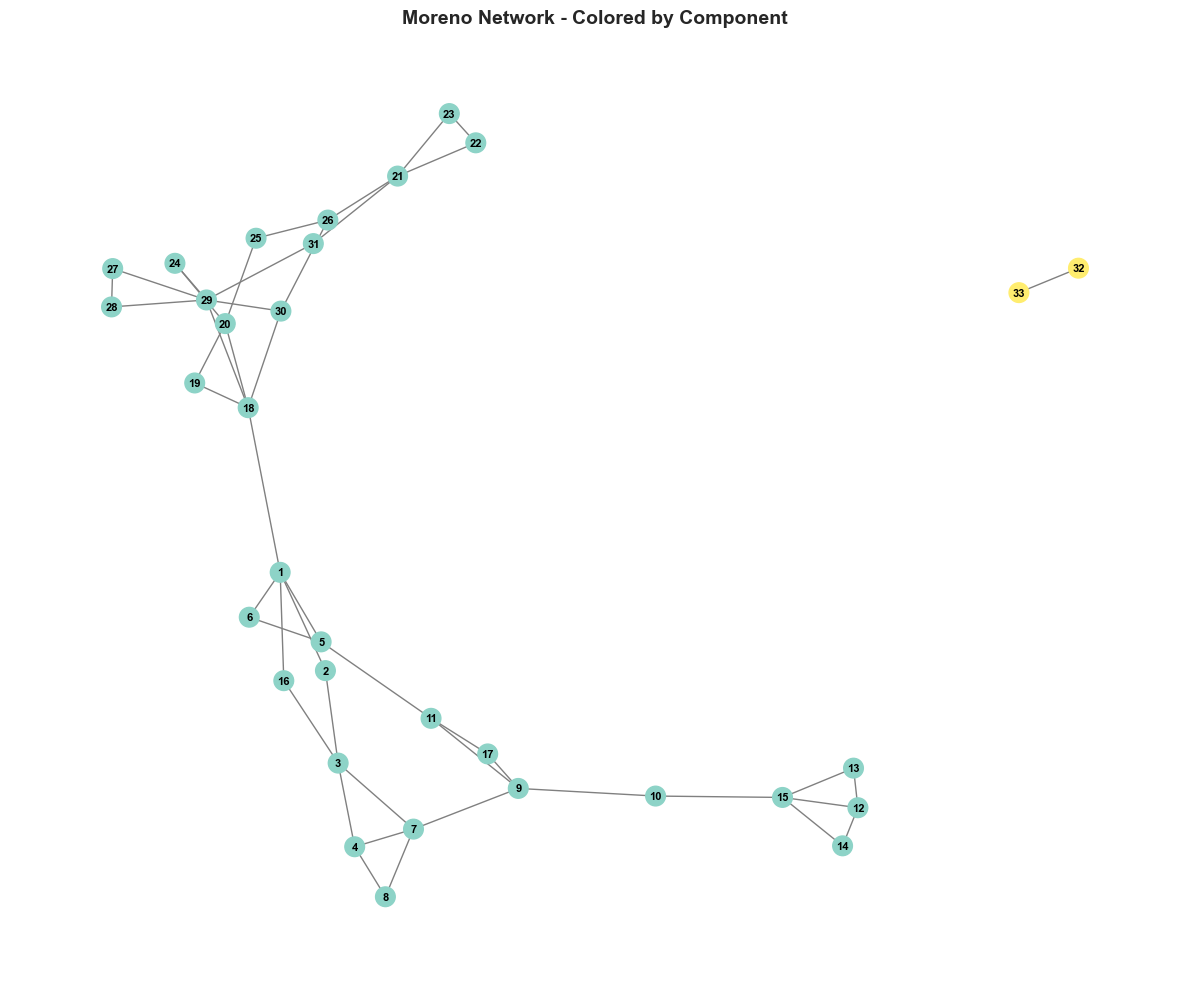

In [12]:
# Visualize network colored by component
fig, ax = plt.subplots(figsize=(12, 10))

# Color nodes by component
node_colors = [component_membership[node] for node in G_moreno.nodes()]

# Use the same layout as before
pos = nx.spring_layout(G_moreno, seed=42)

nx.draw_networkx(
    G_moreno,
    pos,
    node_color=node_colors,
    cmap='Set3',
    node_size=200,
    with_labels=True,
    font_size=8,
    font_weight='bold',
    edge_color='gray',
    ax=ax
)

ax.set_title("Moreno Network - Colored by Component", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

#### Network Diameter and Clustering Coefficient

In this section, we'll explore two additional network metrics: **diameter** and **clustering coefficient**. These measures help us understand the network's compactness and its tendency to form clustered communities.

##### Network Diameter

The **network diameter** is the longest shortest path between any two nodes in the network. It represents the maximum distance needed to travel from one node to another, following the shortest available path.

- A small diameter indicates a compact network where nodes are closely connected
- A large diameter suggests nodes are more spread out

**Important:** For networks with multiple components, we calculate the diameter on the **largest connected component** since disconnected components would have infinite distance between them.

In [13]:
# Get the largest connected component
largest_cc = max(nx.connected_components(G_moreno), key=len)
G_moreno_lcc = G_moreno.subgraph(largest_cc).copy()

print(f"Largest component size: {len(largest_cc)} nodes")

# Calculate diameter
diameter = nx.diameter(G_moreno_lcc)
print(f"Network diameter: {diameter}")
print(f"\nInterpretation: The maximum shortest path between any two nodes is {diameter} steps")

Largest component size: 31 nodes
Network diameter: 11

Interpretation: The maximum shortest path between any two nodes is 11 steps


##### Clustering Coefficient

The **clustering coefficient** (also called **transitivity**) measures the tendency of nodes to form triangles. It represents the proportion of closed triangles (three nodes all connected to each other) relative to all possible triangles in the network.

- A high clustering coefficient indicates that nodes tend to form tight-knit groups
- A low clustering coefficient suggests a more tree-like or sparse structure


In [15]:
# Calculate global clustering coefficient (transitivity)
transitivity = nx.transitivity(G_moreno)
print(f"Global clustering coefficient (transitivity): {transitivity:.4f}")

# Calculate average local clustering coefficient
avg_clustering = nx.average_clustering(G_moreno)

print(f"\nInterpretation: {transitivity*100:.2f}% of connected triples form closed triangles")

Global clustering coefficient (transitivity): 0.2857

Interpretation: 28.57% of connected triples form closed triangles


#### Network Descriptives Cheatsheet

Below is a reference table of the most important functions for network descriptive analysis in Python using **NetworkX**.

| **Task** | **NetworkX Function** | **Description** |
|----------|----------------------|-----------------|
| **Visualize network** | `nx.draw()` or `nx.draw_networkx()` | Create a visualization of the network |
| **Number of nodes** | `G.number_of_nodes()` or `len(G)` | Get the number of nodes (vertices) |
| **Number of edges** | `G.number_of_edges()` | Get the number of edges (connections) |
| **Network density** | `nx.density(G)` | Calculate the proportion of actual vs. possible connections |
| **Connected components** | `nx.number_connected_components(G)` | Count the number of disconnected subgroups |
| **Largest component** | `max(nx.connected_components(G), key=len)` | Get the largest connected component |
| **Network diameter** | `nx.diameter(G)` | Calculate the longest shortest path (on connected graph) |
| **Clustering coefficient** | `nx.transitivity(G)` | Calculate global clustering (closed triangles) |
| **Degree** | `G.degree()` or `G.degree(node)` | Get degree of nodes (number of connections) |

For a complete list of NetworkX functions, consult the [NetworkX documentation](https://networkx.org/documentation/stable/reference/index.html).

### Network Representation

#### Creating Networks from Adjacency Matrices

In this section, we'll learn how to create network objects from **adjacency matrices**. This is a fundamental skill in network analysis, as it allows us to convert raw relational data into a format suitable for analysis and visualization.

An **adjacency matrix** is a square matrix where:
- Rows and columns represent nodes
- A value of 1 (or non-zero) at position [i, j] indicates an edge from node i to node j
- A value of 0 indicates no edge

##### Generating Sample Data

Let's start by creating a simple adjacency matrix representing a network of 5 nodes:

In [16]:
# Create an adjacency matrix using numpy
adjacency_matrix = np.array([
    [0, 1, 1, 0, 0],
    [0, 0, 1, 1, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0]
])

print("Adjacency Matrix:")
print(adjacency_matrix)

Adjacency Matrix:
[[0 1 1 0 0]
 [0 0 1 1 0]
 [0 1 0 0 0]
 [0 0 0 0 0]
 [0 0 1 0 0]]


##### Adding Node Labels

For better interpretability, we can assign meaningful names to our nodes. We'll use a pandas DataFrame to create a labeled adjacency matrix:

In [17]:
# Create a labeled adjacency matrix using pandas
node_names = ['A', 'B', 'C', 'D', 'E']
adjacency_df = pd.DataFrame(adjacency_matrix, index=node_names, columns=node_names)

print("Labeled Adjacency Matrix:")
print(adjacency_df)

Labeled Adjacency Matrix:
   A  B  C  D  E
A  0  1  1  0  0
B  0  0  1  1  0
C  0  1  0  0  0
D  0  0  0  0  0
E  0  0  1  0  0


##### Creating a NetworkX Graph from an Adjacency Matrix

Now we can create a NetworkX graph object from our adjacency matrix. NetworkX provides the `from_numpy_array()` function for this purpose:

In [18]:
# Create a directed graph from the adjacency matrix
adjacency_network = nx.from_numpy_array(adjacency_matrix, create_using=nx.DiGraph())

# Relabel nodes with meaningful names
adjacency_network = nx.relabel_nodes(adjacency_network, {i: name for i, name in enumerate(node_names)})

print(f"Graph type: {type(adjacency_network).__name__}")
print(f"Number of nodes: {adjacency_network.number_of_nodes()}")
print(f"Number of edges: {adjacency_network.number_of_edges()}")

Graph type: DiGraph
Number of nodes: 5
Number of edges: 6


##### Examining the Network

We can get a detailed summary of our network structure:

In [19]:
# Display network properties
print("Network Properties:")
print(f"  Directed: {adjacency_network.is_directed()}")
print(f"  Density: {nx.density(adjacency_network):.2f}")
print(f"  Nodes: {list(adjacency_network.nodes())}")
print(f"  Edges: {list(adjacency_network.edges())}")

Network Properties:
  Directed: True
  Density: 0.30
  Nodes: ['A', 'B', 'C', 'D', 'E']
  Edges: [('A', 'B'), ('A', 'C'), ('B', 'C'), ('B', 'D'), ('C', 'B'), ('E', 'C')]


##### Visualizing the Network

Finally, let's visualize our network to see the structure clearly:

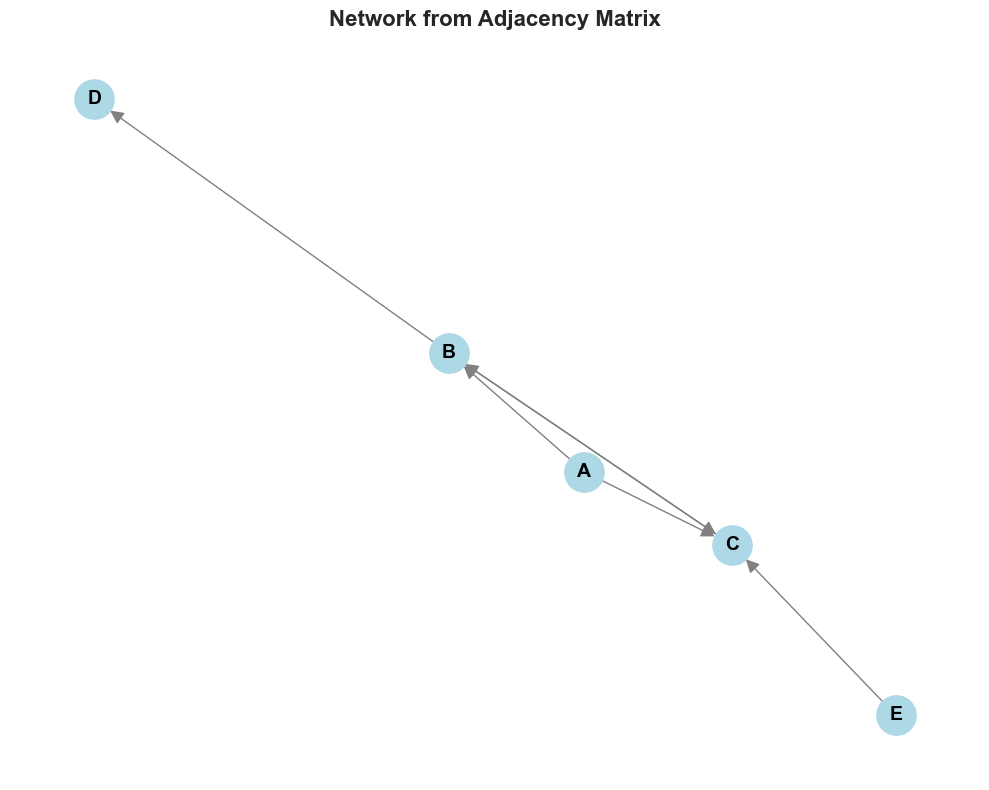

In [20]:
# Visualize the directed network
fig, ax = plt.subplots(figsize=(10, 8))

pos = nx.spring_layout(adjacency_network, seed=42)

nx.draw_networkx(
    adjacency_network,
    pos,
    node_color='lightblue',
    node_size=800,
    with_labels=True,
    font_size=14,
    font_weight='bold',
    arrows=True,
    arrowsize=20,
    edge_color='gray',
    ax=ax
)

ax.set_title("Network from Adjacency Matrix", fontsize=16, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

#### Creating Networks from Edge Lists

Another common way to represent networks is through **edge lists**. An edge list is a simple data structure where each row represents an edge (connection) between two nodes.

An **edge list** consists of:
- Two columns: source node and target node
- Each row represents one edge in the network
- More memory-efficient than adjacency matrices for sparse networks

##### Generating Sample Data

Let's create an edge list representing a simple network:

In [21]:
# Create an edge list using numpy
edge_list = np.array([
    [1, 2],
    [1, 3],
    [2, 3],
    [2, 4],
    [3, 2],
    [5, 3]
])

print("Edge List:")
print(edge_list)

Edge List:
[[1 2]
 [1 3]
 [2 3]
 [2 4]
 [3 2]
 [5 3]]


##### Creating a Network Object from an Edge List

We can create a NetworkX graph directly from an edge list. Since the edge list contains numeric node IDs, we'll create the graph and then assign meaningful names:

In [22]:
# Create a directed graph from the edge list
edge_network = nx.DiGraph()
edge_network.add_edges_from(edge_list)

print(f"Graph type: {type(edge_network).__name__}")
print(f"Number of nodes: {edge_network.number_of_nodes()}")
print(f"Number of edges: {edge_network.number_of_edges()}")
print(f"Edges: {list(edge_network.edges())}")

Graph type: DiGraph
Number of nodes: 5
Number of edges: 6
Edges: [(np.int64(1), np.int64(2)), (np.int64(1), np.int64(3)), (np.int64(2), np.int64(3)), (np.int64(2), np.int64(4)), (np.int64(3), np.int64(2)), (np.int64(5), np.int64(3))]


##### Naming Nodes

To make our network more interpretable, we can assign meaningful names to the nodes using the `relabel_nodes()` function:

In [23]:
# Define node names
node_labels = {1: 'A', 2: 'B', 3: 'C', 4: 'D', 5: 'E'}

# Relabel nodes with meaningful names
edge_network = nx.relabel_nodes(edge_network, node_labels)

print("Nodes with labels:")
print(f"  Nodes: {list(edge_network.nodes())}")
print(f"  Edges: {list(edge_network.edges())}")

Nodes with labels:
  Nodes: ['A', 'B', 'C', 'D', 'E']
  Edges: [('A', 'B'), ('A', 'C'), ('B', 'C'), ('B', 'D'), ('C', 'B'), ('E', 'C')]


##### Converting Between Representations

NetworkX makes it easy to convert between different network representations. We can convert a graph to an adjacency matrix or back to an edge list:

In [24]:
# Convert network to adjacency matrix
adj_matrix = nx.to_numpy_array(edge_network)
print("Adjacency Matrix:")
print(adj_matrix)

# Convert network to edge list (as DataFrame for better readability)
edge_df = nx.to_pandas_edgelist(edge_network)
print("\nEdge List as DataFrame:")
print(edge_df)

Adjacency Matrix:
[[0. 1. 1. 0. 0.]
 [0. 0. 1. 1. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]]

Edge List as DataFrame:
  source target
0      A      B
1      A      C
2      B      C
3      B      D
4      C      B
5      E      C


#### Setting Node Attributes

Node attributes provide additional information about the nodes in a network, such as gender, age, language, or any other characteristic. In `NetworkX`, we can easily add and manage node attributes to enrich our network data.

##### Adding Node Attributes

Let's start by adding gender information to our `adjacency_network` from Section 2.1. In NetworkX, we use `set_node_attributes()` to add attributes to nodes:

In [25]:
# Add gender attribute to adjacency_network
gender_values = {'A': 'F', 'B': 'F', 'C': 'M', 'D': 'F', 'E': 'M'}
nx.set_node_attributes(adjacency_network, gender_values, 'gender')

# Verify the attribute was added
print("Node attributes:")
for node in adjacency_network.nodes():
    print(f"  Node {node}: gender = {adjacency_network.nodes[node]['gender']}")

Node attributes:
  Node A: gender = F
  Node B: gender = F
  Node C: gender = M
  Node D: gender = F
  Node E: gender = M


##### Adding Degree as an Attribute

The **degree** of a node is the number of edges connected to it. We can calculate the degree for each node and add it as an attribute. This is useful for analyzing node importance or centrality:

In [26]:
# Calculate degree for each node
degree_dict = dict(adjacency_network.degree())

# Add degree as a node attribute
nx.set_node_attributes(adjacency_network, degree_dict, 'alldeg')

# Display the degree attribute for each node
print("Node degrees:")
for node in adjacency_network.nodes():
    print(f"  Node {node}: degree = {adjacency_network.nodes[node]['alldeg']}")

Node degrees:
  Node A: degree = 2
  Node B: degree = 4
  Node C: degree = 4
  Node D: degree = 1
  Node E: degree = 1


##### Listing All Node Attributes

We can check what attributes exist in our network by accessing the node data. NetworkX stores attributes in the nodes' data dictionaries:

In [27]:
# Get all unique attribute names across all nodes
all_attributes = set()
for node in adjacency_network.nodes():
    all_attributes.update(adjacency_network.nodes[node].keys())

print("Available node attributes:")
for attr in sorted(all_attributes):
    print(f"  - {attr}")

Available node attributes:
  - alldeg
  - gender


##### Inspecting Attribute Values

There are multiple ways to access node attributes in NetworkX. Here are the most common methods:

In [24]:
# Method 1: Using nx.get_node_attributes() - returns a dictionary
gender_attrs = nx.get_node_attributes(adjacency_network, 'gender')
print("Method 1 - Get all gender attributes:")
print(f"  {gender_attrs}")

# Method 2: Accessing individual node attributes directly
print("\nMethod 2 - Access individual node attributes:")
print(f"  Node A gender: {adjacency_network.nodes['A']['gender']}")
print(f"  Node C gender: {adjacency_network.nodes['C']['gender']}")

# Method 3: Get degree attributes
degree_attrs = nx.get_node_attributes(adjacency_network, 'alldeg')
print("\nMethod 3 - Get all degree attributes:")
print(f"  {degree_attrs}")

Method 1 - Get all gender attributes:
  {'A': 'F', 'B': 'F', 'C': 'M', 'D': 'F', 'E': 'M'}

Method 2 - Access individual node attributes:
  Node A gender: F
  Node C gender: M

Method 3 - Get all degree attributes:
  {'A': 2, 'B': 4, 'C': 4, 'D': 1, 'E': 1}


#### Setting Edge Attributes

Just as we can add attributes to nodes, we can also add attributes to **edges** (connections) in a network. Edge attributes provide additional information about relationships, such as weight, strength, type, or frequency of interaction.

##### Adding Edge Attributes

Let's add a random value attribute to each edge in our `adjacency_network`. In NetworkX, we use `set_edge_attributes()` to add attributes to edges:

In [28]:
# Generate random values for each edge
np.random.seed(42)  # For reproducibility
edge_count = adjacency_network.number_of_edges()
random_values = np.random.uniform(0, 1, edge_count)

# Create a dictionary mapping edges to random values
edge_attr_dict = {edge: random_values[i] for i, edge in enumerate(adjacency_network.edges())}

# Add the attribute to edges
nx.set_edge_attributes(adjacency_network, edge_attr_dict, 'rndval')

# Display edges with their random values
print("Edge attributes (rndval):")
for edge in adjacency_network.edges():
    print(f"  {edge}: {adjacency_network.edges[edge]['rndval']:.4f}")

Edge attributes (rndval):
  ('A', 'B'): 0.3745
  ('A', 'C'): 0.9507
  ('B', 'C'): 0.7320
  ('B', 'D'): 0.5987
  ('C', 'B'): 0.1560
  ('E', 'C'): 0.1560


##### Inspecting Edge Attribute Values

We can retrieve edge attributes using `nx.get_edge_attributes()`, which returns a dictionary mapping edges to their attribute values:

In [29]:
# Get all edge attributes for 'rndval'
rndval_attrs = nx.get_edge_attributes(adjacency_network, 'rndval')
print("All edge 'rndval' attributes:")
print(rndval_attrs)

# Access individual edge attribute
print(f"\nAttribute for edge ('A', 'B'): {adjacency_network.edges[('A', 'B')]['rndval']:.4f}")

All edge 'rndval' attributes:
{('A', 'B'): np.float64(0.3745401188473625), ('A', 'C'): np.float64(0.9507143064099162), ('B', 'C'): np.float64(0.7319939418114051), ('B', 'D'): np.float64(0.5986584841970366), ('C', 'B'): np.float64(0.15601864044243652), ('E', 'C'): np.float64(0.15599452033620265)}

Attribute for edge ('A', 'B'): 0.3745


##### Summary of Edge Attribute Values

We can calculate statistical summaries of edge attributes using pandas or numpy:

In [30]:
# Get all rndval values as a list
rndval_values = list(rndval_attrs.values())

# Calculate summary statistics using pandas
summary = pd.Series(rndval_values).describe()
print("Summary statistics for 'rndval' edge attribute:")
print(summary)

Summary statistics for 'rndval' edge attribute:
count    6.000000
mean     0.494653
std      0.322158
min      0.155995
25%      0.210649
50%      0.486599
75%      0.698660
max      0.950714
dtype: float64


#### Format Conversions & Network Inspection

`NetworkX` provides powerful tools to convert between different network representations and inspect network properties. This section covers bidirectional conversions and comprehensive network summaries.

##### Format Conversions

NetworkX supports seamless conversion between different graph representations:

**Converting TO other formats:**
- `nx.to_pandas_edgelist(G)` - Convert to pandas DataFrame edge list
- `nx.to_numpy_array(G)` - Convert to NumPy adjacency matrix  
- `nx.to_dict_of_dicts(G)` - Convert to nested dictionaries

**Converting FROM other formats:**
- `nx.from_pandas_edgelist(df, source, target)` - Create graph from DataFrame
- `nx.from_numpy_array(array)` - Create graph from adjacency matrix
- `nx.from_dict_of_dicts(d)` - Create graph from nested dictionaries

These conversions are **bidirectional** and preserve network structure and attributes.

In [28]:
# Example: Convert adjacency_network to different formats
print("Original network:")
print(f"  Nodes: {adjacency_network.number_of_nodes()}, Edges: {adjacency_network.number_of_edges()}")

# Convert to pandas edge list
edge_df = nx.to_pandas_edgelist(adjacency_network)
print("\nEdge list as DataFrame:")
print(edge_df.head())

# Convert to numpy adjacency matrix
adj_array = nx.to_numpy_array(adjacency_network)
print("\nAdjacency matrix shape:", adj_array.shape)

# Recreate graph from the edge list DataFrame
G_from_df = nx.from_pandas_edgelist(edge_df, source='source', target='target', create_using=nx.DiGraph())
print(f"\nRecreated graph: {G_from_df.number_of_nodes()} nodes, {G_from_df.number_of_edges()} edges")

Original network:
  Nodes: 5, Edges: 6

Edge list as DataFrame:
  source target    rndval  weight
0      A      B  0.374540       1
1      A      C  0.950714       1
2      B      C  0.731994       1
3      B      D  0.598658       1
4      C      B  0.156019       1

Adjacency matrix shape: (5, 5)

Recreated graph: 5 nodes, 6 edges


### Network Visualization

Visualizing networks is crucial for understanding their structure and characteristics. In this section, we'll learn how to create effective network visualizations using `NetworkX` and `matplotlib`, exploring different layout algorithms and customization options.

#### Layout Algorithms

`NetworkX` provides several layout algorithms to position nodes in a 2D space. Let's start by visualizing the Moreno network using two different layouts:

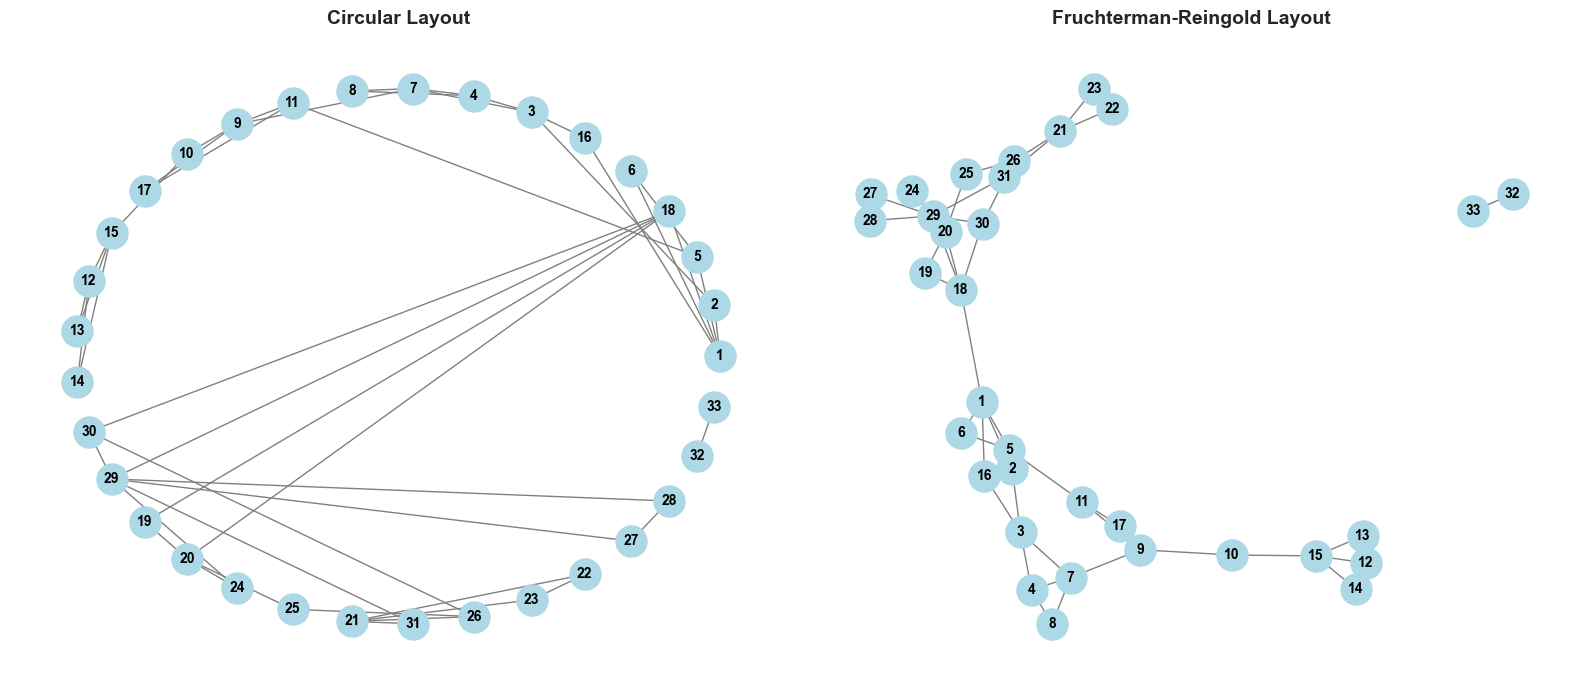

In [32]:
# Create side-by-side visualizations with different layouts
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Layout 1: Circular layout
pos_circle = nx.circular_layout(G_moreno)
nx.draw_networkx(G_moreno, pos_circle, node_size=500, node_color='lightblue',
                 with_labels=True, font_size=10, font_weight='bold',
                 edge_color='gray', ax=axes[0])
axes[0].set_title("Circular Layout", fontsize=14, fontweight='bold')
axes[0].axis('off')

# Layout 2: Fruchterman-Reingold layout / force-directed
pos_spring = nx.spring_layout(G_moreno, seed=42)
nx.draw_networkx(G_moreno, pos_spring, node_size=500, node_color='lightblue',
                 with_labels=True, font_size=10, font_weight='bold',
                 edge_color='gray', ax=axes[1])
axes[1].set_title("Fruchterman-Reingold Layout", fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

**Layout Algorithms in NetworkX:**

NetworkX provides several layout algorithms to position nodes. Here are the most commonly used:

| **Layout** | **NetworkX Function** | **Description** |
|------------|----------------------|-----------------|
| Circular | `nx.circular_layout()` | Positions nodes in a circle |
| Spring/Fruchterman-Reingold | `nx.spring_layout()` | Force-directed layout, aesthetically pleasing |
| Random | `nx.random_layout()` | Random positioning |
| Kamada-Kawai | `nx.kamada_kawai_layout()` | Force-directed, good for small graphs |
| Shell | `nx.shell_layout()` | Concentric circles |
| Spectral | `nx.spectral_layout()` | Based on graph Laplacian eigenvalues |

The **Fruchterman-Reingold** algorithm (implemented in `spring_layout()`) is particularly effective as it treats edges as springs and nodes as repelling particles, creating balanced and readable visualizations.

#### Basic Plotting

Let's create a single, more detailed visualization using the Fruchterman-Reingold layout:

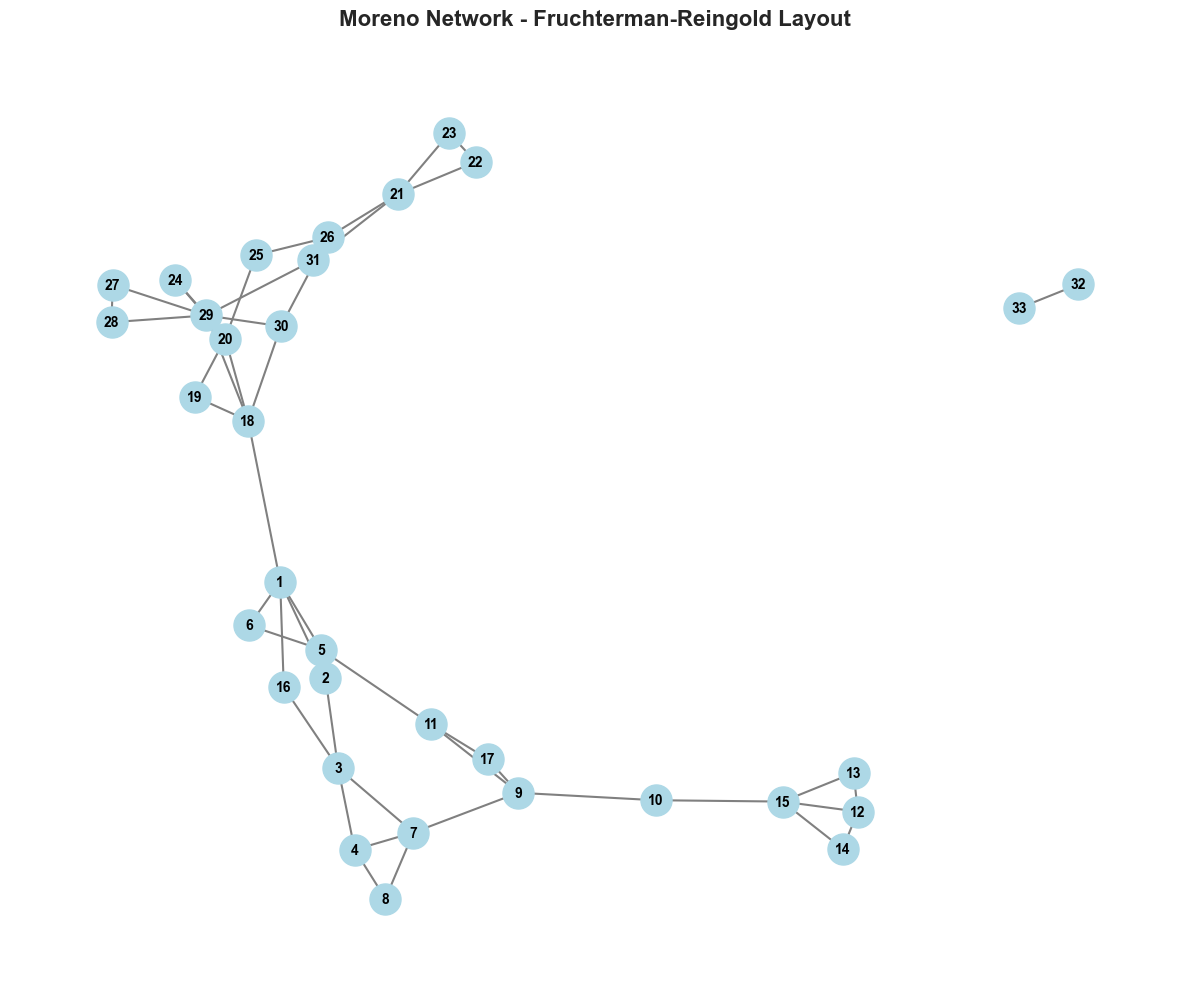

In [33]:
# Create a single visualization with Fruchterman-Reingold layout
fig, ax = plt.subplots(figsize=(12, 10))

# Use spring layout (Fruchterman-Reingold algorithm)
pos = nx.spring_layout(G_moreno, seed=42)

# Draw the network
nx.draw_networkx(G_moreno, pos, node_size=500, node_color='lightblue',
                 with_labels=True, font_size=10, font_weight='bold',
                 edge_color='gray', width=1.5, ax=ax)

ax.set_title("Moreno Network - Fruchterman-Reingold Layout", 
             fontsize=16, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

#### Customization Options

You can customize network visualizations by changing node colors, labels, and sizes. This is particularly useful for highlighting node attributes or emphasizing certain aspects of the network structure.

Let's create a network and customize its visualization by varying node sizes and coloring nodes by attributes:

In [35]:
# Create a custom network from adjacency matrix
adjacency_custom = np.array([
    [0, 1, 1, 0, 0],
    [0, 0, 1, 1, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0]
])

# Create directed graph
net_custom = nx.from_numpy_array(adjacency_custom, create_using=nx.DiGraph())
net_custom = nx.relabel_nodes(net_custom, {i: chr(65+i) for i in range(5)})  # A, B, C, D, E

# Add gender attribute
gender_attrs = {'A': 'F', 'B': 'F', 'C': 'M', 'D': 'F', 'E': 'M'}
nx.set_node_attributes(net_custom, gender_attrs, 'gender')

print("Custom network created with gender attributes:")
for node in net_custom.nodes():
    print(f"  Node {node}: gender = {net_custom.nodes[node]['gender']}")

Custom network created with gender attributes:
  Node A: gender = F
  Node B: gender = F
  Node C: gender = M
  Node D: gender = F
  Node E: gender = M


#### Comparing Node Sizes

Let's visualize the network with different node sizes to demonstrate the effect:

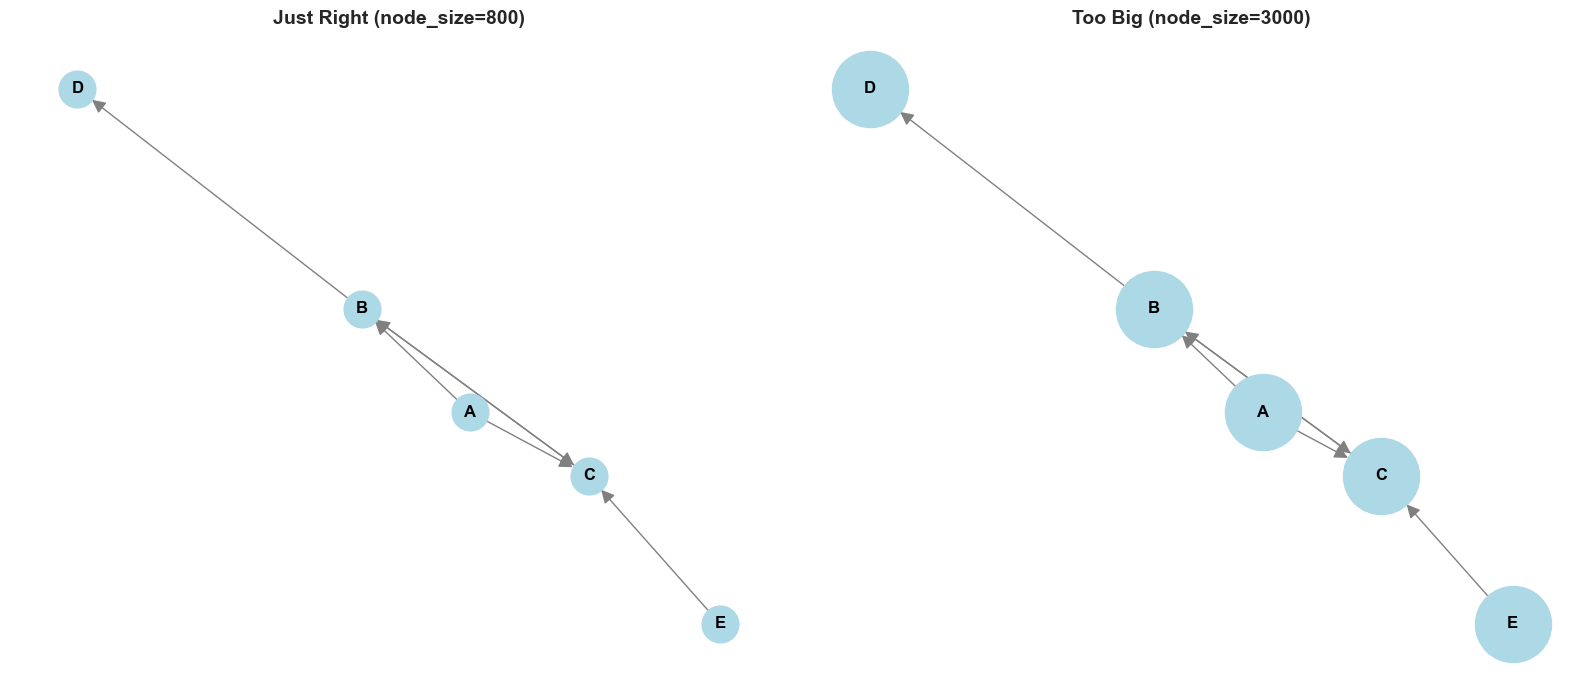

In [36]:
# Create side-by-side comparisons with different node sizes
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Use consistent layout
pos = nx.spring_layout(net_custom, seed=42)

# Plot 1: Normal size (just right)
nx.draw_networkx(net_custom, pos, node_size=700, node_color='lightblue',
                 with_labels=True, font_size=12, font_weight='bold',
                 arrows=True, arrowsize=20, edge_color='gray', ax=axes[0])
axes[0].set_title("Just Right (node_size=800)", fontsize=14, fontweight='bold')
axes[0].axis('off')

# Plot 2: Too big
nx.draw_networkx(net_custom, pos, node_size=3000, node_color='lightblue',
                 with_labels=True, font_size=12, font_weight='bold',
                 arrows=True, arrowsize=20, edge_color='gray', ax=axes[1])
axes[1].set_title("Too Big (node_size=3000)", fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

#### Coloring Nodes by Attributes

One of the most powerful visualization techniques is coloring nodes based on their attributes. Let's color nodes by gender and add gender labels:

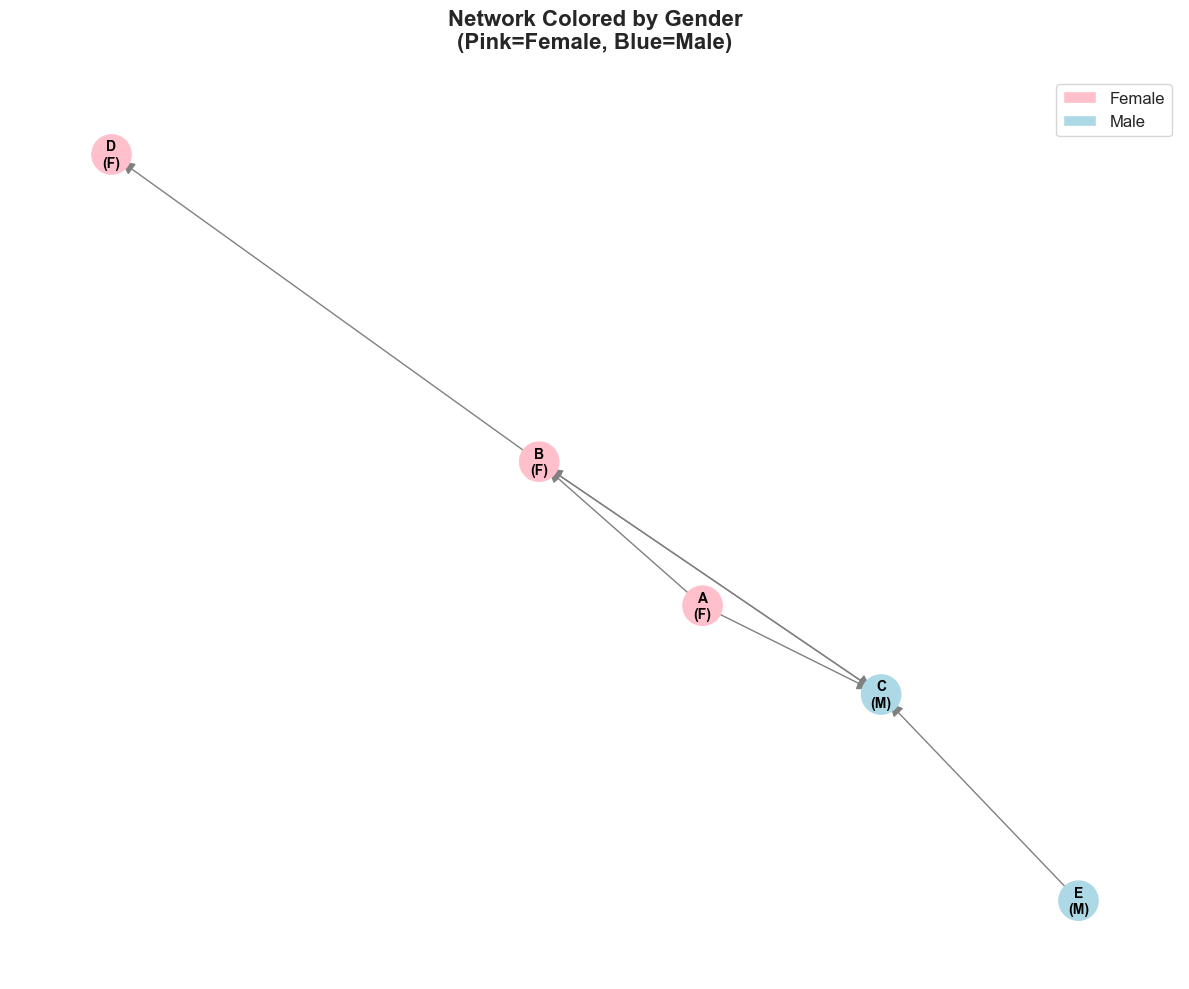

In [37]:
# Create visualization with nodes colored by gender
fig, ax = plt.subplots(figsize=(12, 10))

# Get gender attributes for coloring
gender_values = nx.get_node_attributes(net_custom, 'gender')

# Map gender to colors: F=pink, M=lightblue
color_map = {'F': 'pink', 'M': 'lightblue'}
node_colors = [color_map[gender_values[node]] for node in net_custom.nodes()]

# Create labels showing both node name and gender
labels = {node: f"{node}\n({gender_values[node]})" for node in net_custom.nodes()}

# Draw the network with colored nodes
pos = nx.spring_layout(net_custom, seed=42)
nx.draw_networkx_nodes(net_custom, pos, node_color=node_colors, node_size=800, ax=ax)
nx.draw_networkx_edges(net_custom, pos, edge_color='gray', arrows=True, 
                       arrowsize=20, ax=ax)
nx.draw_networkx_labels(net_custom, pos, labels=labels, font_size=10, 
                        font_weight='bold', ax=ax)

ax.set_title("Network Colored by Gender\n(Pink=Female, Blue=Male)", 
             fontsize=16, fontweight='bold', pad=20)
ax.axis('off')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='pink', label='Female'),
                   Patch(facecolor='lightblue', label='Male')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

**Customization Options:**

NetworkX's `draw_networkx()` and related functions offer extensive customization options:

| **Parameter** | **Purpose** | **Example Values** |
|---------------|-------------|-------------------|
| `node_size` | Size of nodes | 300, 800, 3000 |
| `node_color` | Color of nodes | 'blue', ['red', 'blue'], attribute list |
| `node_shape` | Shape of nodes | 'o' (circle), 's' (square), '^' (triangle) |
| `with_labels` | Show node labels | True, False |
| `font_size` | Label text size | 8, 10, 12 |
| `font_weight` | Label text weight | 'normal', 'bold' |
| `edge_color` | Color of edges | 'gray', 'black' |
| `width` | Edge line width | 1.0, 2.0, 3.0 |
| `arrows` | Show edge direction | True, False (for directed graphs) |
| `arrowsize` | Size of arrow heads | 10, 20, 30 |

**Pro Tip:** For more advanced visualizations, you can use `draw_networkx_nodes()`, `draw_networkx_edges()`, and `draw_networkx_labels()` separately for finer control over each element.

### Centrality Measures in Network Analysis

Centrality measures are crucial in network analysis as they provide insights into the individual characteristics of nodes (vertices) within a network. In this section, we'll explore three key centrality measures: **degree**, **closeness**, and **betweenness**. These metrics help us identify important or influential nodes in a network.

#### Network Creation

First, let's create a network using an adjacency matrix. Each row and column represents a node, and a value of 1 indicates a connection between the corresponding nodes.

In [38]:
# Create adjacency matrix for centrality analysis
netmat = np.array([
    [0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 0, 1, 1, 0, 1, 0, 0, 0],
    [0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 1, 0, 0, 0],
    [0, 0, 1, 0, 0, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
])

# Define node names
node_names = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']

# Create undirected graph from adjacency matrix
net = nx.from_numpy_array(netmat, create_using=nx.Graph())
net = nx.relabel_nodes(net, {i: name for i, name in enumerate(node_names)})

print(f"Network created with {net.number_of_nodes()} nodes and {net.number_of_edges()} edges")
print(f"Nodes: {list(net.nodes())}")

Network created with 10 nodes and 12 edges
Nodes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']


#### Degree Centrality

**Degree centrality** refers to the number of edges that are adjacent to a certain vertex. The degree ($d$) of a vertex ($v$) is the number of edges adjacent to this vertex. Nodes with higher degree centrality are more connected and potentially more influential in the network. A vertex with a large degree is called a **hub**.

In [42]:
# Calculate degree centrality
degree_cent = dict(net.degree())

print("Degree Centrality:")
for node in node_names:
    print(f"  {node}: {degree_cent[node]}")

# Display as array (similar to R output)
degree_values = [degree_cent[node] for node in node_names]
print(f"\nDegree values: {degree_values}")

Degree Centrality:
  A: 2
  B: 2
  C: 5
  D: 2
  E: 3
  F: 2
  G: 3
  H: 3
  I: 1
  J: 1

Degree values: [2, 2, 5, 2, 3, 2, 3, 3, 1, 1]


**Interpretation:** Node C has the highest degree (5 connections), making it the most connected node in the network. Nodes I and J have the lowest degree (1 connection each).

#### Closeness Centrality

**Closeness centrality** measures the distance to every other vertex in the network. It indicates how close a node is to all other nodes. Nodes with higher closeness centrality can reach other nodes more quickly.

In NetworkX, we use `closeness_centrality()`:


In [39]:
# Calculate closeness centrality
closeness_cent = nx.closeness_centrality(net)

print("Closeness Centrality:")
for node in node_names:
    print(f"  {node}: {closeness_cent[node]:.7f}")

Closeness Centrality:
  A: 0.4090909
  B: 0.4090909
  C: 0.6000000
  D: 0.4285714
  E: 0.4500000
  F: 0.4500000
  G: 0.6000000
  H: 0.4736842
  I: 0.3333333
  J: 0.3333333


**Interpretation:** Nodes C and G have the highest closeness centrality (0.6), meaning they are the most central in terms of reaching other nodes quickly. Nodes I and J have the lowest closeness centrality (approximately 0.33).

#### Betweenness Centrality

**Betweenness centrality** quantifies the fraction of shortest paths between any pair of vertices that pass through a given vertex. It measures the influence of a node over the flow of information in the network. Nodes with high betweenness centrality are critical for connecting different parts of the network.

In NetworkX, we use `betweenness_centrality()`:

In [40]:
# Calculate betweenness centrality
betweenness_cent = nx.betweenness_centrality(net)

print("Betweenness Centrality:")
for node in node_names:
    print(f"  {node}: {betweenness_cent[node]:.3f}")


Betweenness Centrality:
  A: 0.000
  B: 0.000
  C: 0.556
  D: 0.000
  E: 0.069
  F: 0.056
  G: 0.542
  H: 0.417
  I: 0.000
  J: 0.000


**Interpretation:** Node C has the highest betweenness centrality (0.556), followed by node G (0.542) and node H (0.417). These nodes serve as critical bridges in the network. Nodes A, B, D, I, and J have betweenness of 0.0, meaning they don't lie on any shortest paths between other node pairs.

#### Visualizing Centrality Measures

Let's visualize the network with node sizes proportional to their centrality measures:

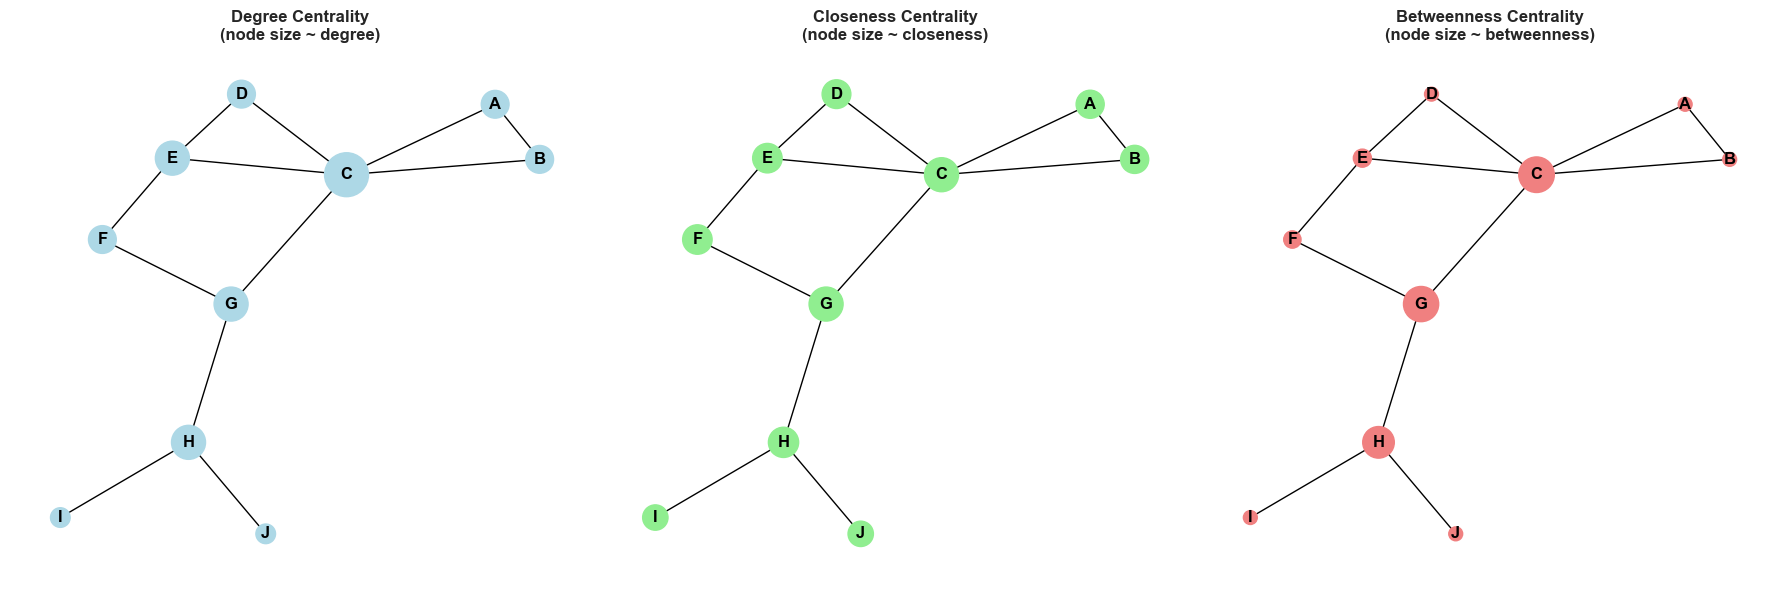

In [43]:
# Create a visualization comparing centrality measures
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Use consistent layout for all plots
pos = nx.spring_layout(net, seed=42)

# 1. Degree centrality
node_sizes_degree = [degree_cent[node] * 200 for node in net.nodes()]
nx.draw_networkx(net, pos, node_size=node_sizes_degree, node_color='lightblue', 
                 with_labels=True, font_weight='bold', ax=axes[0])
axes[0].set_title("Degree Centrality\n(node size ~ degree)", fontsize=12, fontweight='bold')
axes[0].axis('off')

# 2. Closeness centrality
node_sizes_closeness = [closeness_cent[node] * 1000 for node in net.nodes()]
nx.draw_networkx(net, pos, node_size=node_sizes_closeness, node_color='lightgreen',
                 with_labels=True, font_weight='bold', ax=axes[1])
axes[1].set_title("Closeness Centrality\n(node size ~ closeness)", fontsize=12, fontweight='bold')
axes[1].axis('off')

# 3. Betweenness centrality
node_sizes_betweenness = [betweenness_cent[node] * 1000 + 100 for node in net.nodes()]
nx.draw_networkx(net, pos, node_size=node_sizes_betweenness, node_color='lightcoral',
                 with_labels=True, font_weight='bold', ax=axes[2])
axes[2].set_title("Betweenness Centrality\n(node size ~ betweenness)", fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Community Detection and Clustering

#### Network Clustering

Network clustering identifies groups of nodes that are more densely connected within groups than between them.

##### Measuring Clustering Quality

**Trace**: The fraction of edges connecting vertices in the same cluster.

**Problem with Trace**: High values can be achieved by placing all nodes in a single cluster (Trace = 1).

**Modularity (Q)**: Fraction of ties within groups minus expected ties under random distribution.

**Modularity values:**
- $Q = 0$: No better than random
- $Q = 1$: Perfect clustering
- $Q = -1$: No within-cluster linkage
- Common values: [0.30 - 0.70]

#### Understanding Network Clustering Metrics: trace_e and Modularity Q

In network clustering, it's crucial to have reliable metrics to evaluate the quality of clusters. Two important measures are **trace_e** and **modularity Q**. This section demonstrates their behavior in different clustering scenarios and explains why modularity Q is superior to trace_e.


Let's examine three scenarios to understand why Q is superior to trace_e:

##### Scenario 1: Optimal Cluster Structure (High Diagonal Values)

In an optimal cluster structure, diagonal values are high (many intra-cluster connections), and off-diagonal values are low (few inter-cluster connections). Both trace_e and Q should be high

In [56]:
# Scenario 1: Optimal cluster structure
e1 = pd.DataFrame({
    'Cluster1': [0.200, 0.050, 0.025],
    'Cluster2': [0.050, 0.300, 0.100],
    'Cluster3': [0.025, 0.100, 0.150]
}, index=['Cluster1', 'Cluster2', 'Cluster3'])

print("Scenario 1: Optimal Cluster Structure")
print("=" * 50)
print("\nEdge matrix (e):")
print(e1)

# Verify sum equals 1
print(f"\nSum of all elements: {e1.values.sum():.3f} (should be 1.0)")

# Calculate row and column sums
a1 = e1.sum(axis=1)
b1 = e1.sum(axis=0)
print(f"\nRow sums (a): {a1.values}")
print(f"Column sums (b): {b1.values}")
print("(Row and column sums should be equal for undirected networks)")

Scenario 1: Optimal Cluster Structure

Edge matrix (e):
          Cluster1  Cluster2  Cluster3
Cluster1     0.200      0.05     0.025
Cluster2     0.050      0.30     0.100
Cluster3     0.025      0.10     0.150

Sum of all elements: 1.000 (should be 1.0)

Row sums (a): [0.275 0.45  0.275]
Column sums (b): [0.275 0.45  0.275]
(Row and column sums should be equal for undirected networks)


In [58]:
# Calculate the random null model matrix
rand1 = pd.DataFrame(index=e1.index, columns=e1.columns)
for i in range(len(a1)):
    for j in range(len(b1)):
        rand1.iloc[i, j] = a1.iloc[i] * b1.iloc[j]

print("\nNull model matrix (expected edges under random model):")
print(rand1)

# Calculate trace_e (BAD measure - doesn't account for random expectation)
trace_e1 = np.trace(e1.values)
print(f"\n{'='*50}")
print(f"BAD measure - trace_e: {trace_e1:.2f}")
print("(Fraction of edges within clusters, but ignores random expectation)")

# Calculate modularity Q (GOOD measure - compares to random expectation)
Q1 = np.trace(e1.values) - np.trace(rand1.values.astype(float))
print(f"\nGOOD measure - Modularity Q: {Q1:.5f}")
print("(Compares actual clustering to random baseline)")
print(f"\nInterpretation: Q = {Q1:.3f} indicates strong community structure")


Null model matrix (expected edges under random model):
          Cluster1 Cluster2  Cluster3
Cluster1  0.075625  0.12375  0.075625
Cluster2   0.12375   0.2025   0.12375
Cluster3  0.075625  0.12375  0.075625

BAD measure - trace_e: 0.65
(Fraction of edges within clusters, but ignores random expectation)

GOOD measure - Modularity Q: 0.29625
(Compares actual clustering to random baseline)

Interpretation: Q = 0.296 indicates strong community structure


##### Scenario 2: Poor Cluster Structure (Low Diagonal Values)

In this scenario, diagonal values are low (few intra-cluster connections), meaning nodes are more connected to other clusters than their own. Both trace_e and Q will be low, but Q will even be **negative**, correctly indicating the clustering is worse than random.

In [59]:
# Scenario 2: Poor cluster structure
e2 = pd.DataFrame({
    'Cluster1': [0.05, 0.20, 0.15],
    'Cluster2': [0.20, 0.025, 0.10],
    'Cluster3': [0.15, 0.100, 0.025]
}, index=['Cluster1', 'Cluster2', 'Cluster3'])

print("Scenario 2: Poor Cluster Structure")
print("=" * 50)
print("\nEdge matrix (e):")
print(e2)
print("\nNotice: Low diagonal values (0.05, 0.025, 0.025)")
print("        High off-diagonal values (inter-cluster connections)")

# Calculate sums
a2 = e2.sum(axis=1)
b2 = e2.sum(axis=0)

# Calculate null model
rand2 = pd.DataFrame(index=e2.index, columns=e2.columns)
for i in range(len(a2)):
    for j in range(len(b2)):
        rand2.iloc[i, j] = a2.iloc[i] * b2.iloc[j]

# Calculate metrics
trace_e2 = np.trace(e2.values)
Q2 = np.trace(e2.values) - np.trace(rand2.values.astype(float))

print(f"\n{'='*50}")
print(f"BAD measure - trace_e: {trace_e2:.2f}")
print(f"(This is low, which correctly shows poor clustering)")

print(f"\nGOOD measure - Modularity Q: {Q2:.5f}")
print(f"(NEGATIVE Q indicates clustering is worse than random!)")
print(f"\nInterpretation: Q = {Q2:.3f} < 0 means this clustering is worse than random")

Scenario 2: Poor Cluster Structure

Edge matrix (e):
          Cluster1  Cluster2  Cluster3
Cluster1      0.05     0.200     0.150
Cluster2      0.20     0.025     0.100
Cluster3      0.15     0.100     0.025

Notice: Low diagonal values (0.05, 0.025, 0.025)
        High off-diagonal values (inter-cluster connections)

BAD measure - trace_e: 0.10
(This is low, which correctly shows poor clustering)

GOOD measure - Modularity Q: -0.24125
(NEGATIVE Q indicates clustering is worse than random!)

Interpretation: Q = -0.241 < 0 means this clustering is worse than random


##### Scenario 3: High Within-Cluster Links for Only One Cluster

In this scenario, we'll see why trace_e can be misleading. We'll create a clustering where only ONE cluster has strong internal connections, while the other two clusters are poorly defined. This will give us the **same trace_e as Scenario 1**, but a much **lower Q** value, demonstrating that Q is the superior metric.

In [60]:
# Scenario 3: Unbalanced clustering (one strong cluster, two weak)
e3 = pd.DataFrame({
    'Cluster1': [0.65, 0.15, 0.10],
    'Cluster2': [0.15, 0.00, 0.05],
    'Cluster3': [0.10, 0.05, 0.00]
}, index=['Cluster1', 'Cluster2', 'Cluster3'])

print("Scenario 3: Unbalanced Cluster Structure")
print("=" * 50)
print("\nEdge matrix (e):")
print(e3)
print("\nNotice: Only Cluster1 has high diagonal (0.65)")
print("        Cluster2 and Cluster3 have zero diagonal (no internal connections)")

# Calculate sums
a3 = e3.sum(axis=1)
b3 = e3.sum(axis=0)

# Calculate null model
rand3 = pd.DataFrame(index=e3.index, columns=e3.columns)
for i in range(len(a3)):
    for j in range(len(b3)):
        rand3.iloc[i, j] = a3.iloc[i] * b3.iloc[j]

# Calculate metrics
trace_e3 = np.trace(e3.values)
Q3 = np.trace(e3.values) - np.trace(rand3.values.astype(float))

print(f"\n{'='*50}")
print(f"BAD measure - trace_e: {trace_e3:.2f}")
print(f"(SAME as Scenario 1! trace_e fails to detect the problem)")

print(f"\nGOOD measure - Modularity Q: {Q3:.5f}")
print(f"(MUCH LOWER than Scenario 1's Q={Q1:.3f})")

print(f"\n{'='*50}")
print("CRITICAL COMPARISON:")
print(f"  Scenario 1: trace_e={trace_e1:.2f}, Q={Q1:.3f}")
print(f"  Scenario 3: trace_e={trace_e3:.2f}, Q={Q3:.3f}")
print("\nConclusion: trace_e can't distinguish between balanced and unbalanced clustering.")
print("            Q correctly identifies that Scenario 3 is barely better than random!")

Scenario 3: Unbalanced Cluster Structure

Edge matrix (e):
          Cluster1  Cluster2  Cluster3
Cluster1      0.65      0.15      0.10
Cluster2      0.15      0.00      0.05
Cluster3      0.10      0.05      0.00

Notice: Only Cluster1 has high diagonal (0.65)
        Cluster2 and Cluster3 have zero diagonal (no internal connections)

BAD measure - trace_e: 0.65
(SAME as Scenario 1! trace_e fails to detect the problem)

GOOD measure - Modularity Q: -0.22250
(MUCH LOWER than Scenario 1's Q=0.296)

CRITICAL COMPARISON:
  Scenario 1: trace_e=0.65, Q=0.296
  Scenario 3: trace_e=0.65, Q=-0.223

Conclusion: trace_e can't distinguish between balanced and unbalanced clustering.
            Q correctly identifies that Scenario 3 is barely better than random!


#### Clustering Based on Known Attributes

Let's now use modularity to check the clustering quality when we have a known clustering variable, such as gender in the Moreno network:

In [44]:
# Examine the gender distribution in the Moreno network
gender_attrs = nx.get_node_attributes(G_moreno, 'gender')

# Count nodes by gender
gender_counts = pd.Series(gender_attrs.values()).value_counts().sort_index()
print("Gender distribution in Moreno network:")
print(gender_counts)
print(f"\nTotal nodes: {len(gender_attrs)}")

# Convert gender values to numeric for modularity calculation
# Gender 1 and 2 in the data correspond to two gender categories
gender_numeric = list(gender_attrs.values())

Gender distribution in Moreno network:
1    16
2    17
Name: count, dtype: int64

Total nodes: 33


Now let's calculate the modularity based on the gender attribute:

In [45]:
# Calculate modularity based on gender clustering
# Create a list of communities (one per gender)
communities_gender = []
for gender_value in sorted(set(gender_numeric)):
    community = [node for node, gender in gender_attrs.items() if gender == gender_value]
    communities_gender.append(community)

# Calculate modularity
modularity_gender = nx.community.modularity(G_moreno, communities_gender)
print(f"Modularity (Q) based on gender clustering: {modularity_gender:.4f}")
print(f"\nInterpretation: Q = {modularity_gender:.2f} indicates {'moderate' if modularity_gender > 0.3 else 'weak'} community structure.")

Modularity (Q) based on gender clustering: 0.4761

Interpretation: Q = 0.48 indicates moderate community structure.


#### Network Clustering with Facebook Data

Now let's examine the Facebook network, where nodes have a `group` attribute representing different social contexts (family, college, work, etc.):

In [46]:
# Load Facebook network data
# Load edges
facebook_edges = pd.read_csv("Data/Facebook_edgelist.csv")
G_facebook = nx.from_pandas_edgelist(facebook_edges, source='from', target='to')

# Load node attributes
facebook_nodes = pd.read_csv("Data/Facebook_nodes.csv")
group_dict = dict(zip(facebook_nodes['name'], facebook_nodes['group']))
nx.set_node_attributes(G_facebook, group_dict, 'group')

print(f"Facebook network loaded: {G_facebook.number_of_nodes()} nodes, {G_facebook.number_of_edges()} edges")

# Display group labels
group_labels = ['B', 'C', 'F', 'G', 'H', 'M', 'S', 'W']
n_fb_nodes = G_facebook.number_of_nodes()

# Get node groups from loaded attributes
node_groups = nx.get_node_attributes(G_facebook, 'group')

# Display group distribution
group_values = list(node_groups.values())
group_distribution = pd.Series(group_values).value_counts().sort_index()
print("\nGroup labels in Facebook network:")
print("  B = Book club")
print("  C = College")
print("  F = Family")
print("  G = Graduate school")
print("  H = High school")
print("  M = Music")
print("  S = Spiel (game)")
print("  W = Work")
print(f"\nGroup distribution:")
print(group_distribution)

Facebook network loaded: 90 nodes, 323 edges

Group labels in Facebook network:
  B = Book club
  C = College
  F = Family
  G = Graduate school
  H = High school
  M = Music
  S = Spiel (game)
  W = Work

Group distribution:
B     5
C     5
F    23
G    10
H     4
M    16
S     6
W    21
Name: count, dtype: int64


In [47]:
# Calculate modularity based on group clustering
communities_groups = []
for group_label in group_labels:
    community = [node for node, group in node_groups.items() if group == group_label]
    if community:  # Only add non-empty communities
        communities_groups.append(community)

modularity_groups = nx.community.modularity(G_facebook, communities_groups)
print(f"\nModularity (Q) based on group clustering: {modularity_groups:.4f}")
print(f"\nComparison:")
print(f"  Moreno (gender):    Q = {modularity_gender:.4f}")
print(f"  Facebook (groups):  Q = {modularity_groups:.4f}")


Modularity (Q) based on group clustering: 0.6146

Comparison:
  Moreno (gender):    Q = 0.4761
  Facebook (groups):  Q = 0.6146


##### Visualizing Communities by Color

Let's visualize the Facebook network with nodes colored by their group membership:

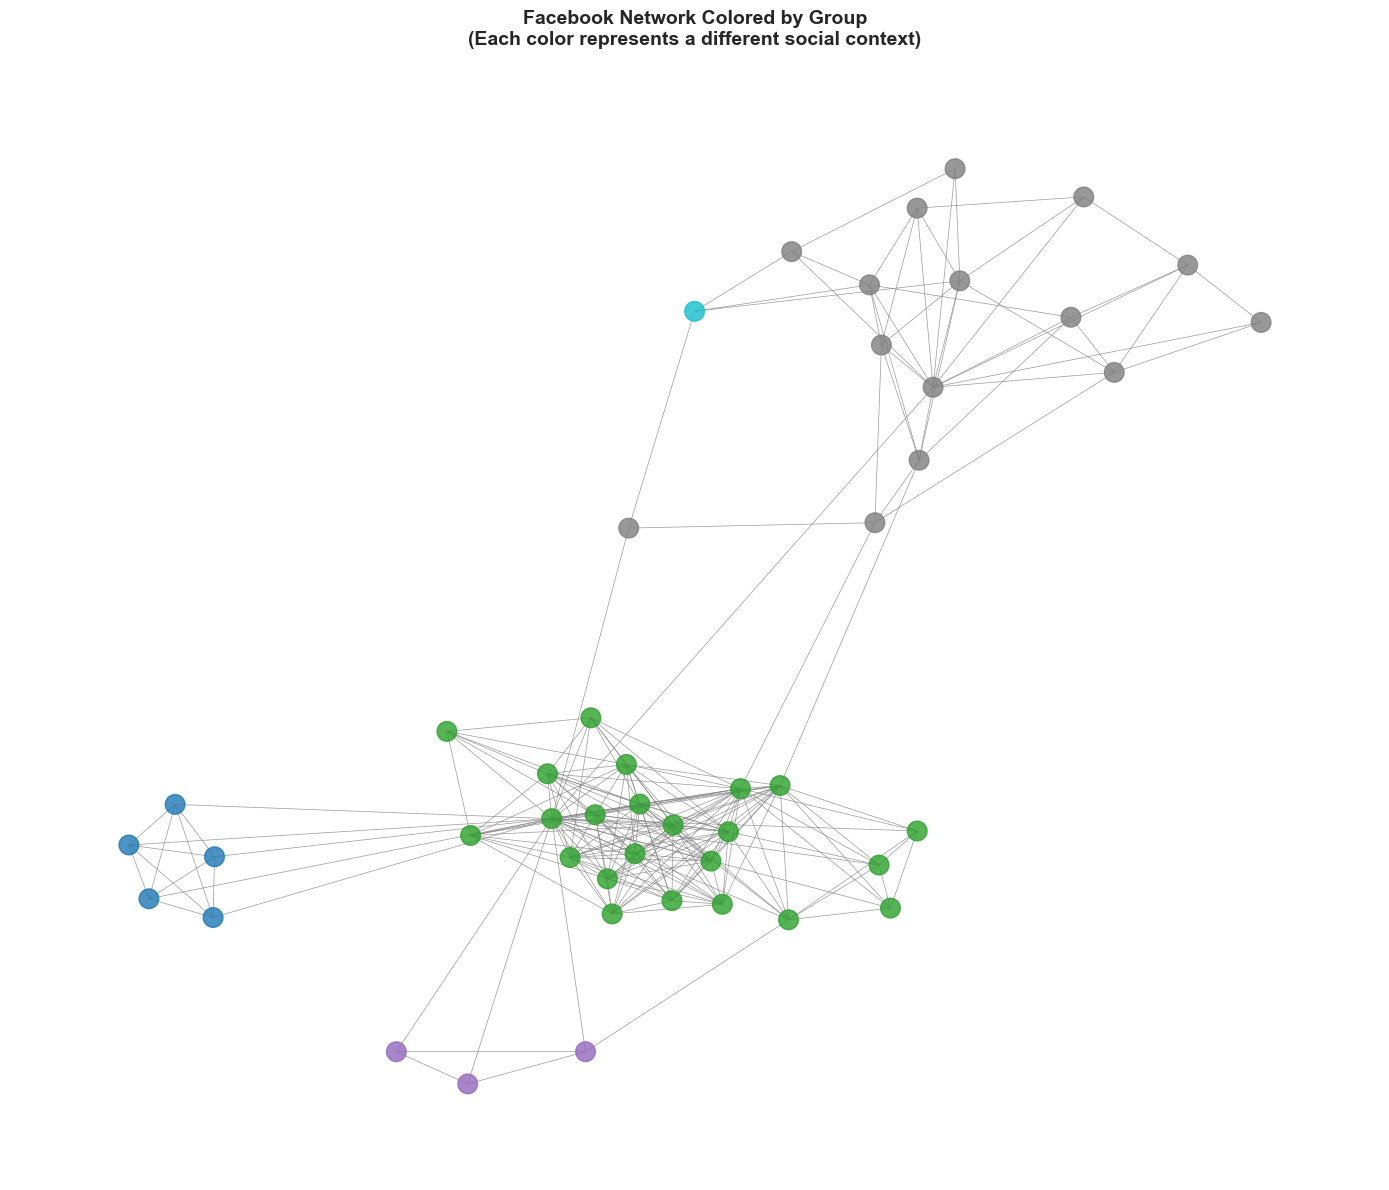

Displaying largest connected component with 47 nodes


In [48]:
# Create visualization with nodes colored by group
fig, ax = plt.subplots(figsize=(14, 12))

# Map groups to numeric values for coloring
group_to_num = {label: i for i, label in enumerate(group_labels)}
node_colors_fb = [group_to_num[node_groups[node]] for node in G_facebook.nodes()]

# Use largest connected component for better visualization
fb_lcc = max(nx.connected_components(G_facebook), key=len)
G_fb_lcc = G_facebook.subgraph(fb_lcc).copy()
node_colors_lcc = [group_to_num[node_groups[node]] for node in G_fb_lcc.nodes()]

# Create layout
pos_fb = nx.spring_layout(G_fb_lcc, seed=42, k=0.3)

# Draw network
nx.draw_networkx(G_fb_lcc, pos_fb, 
                 node_color=node_colors_lcc,
                 cmap='tab10',
                 node_size=200,
                 with_labels=False,
                 edge_color='gray',
                 width=0.5,
                 alpha=0.8,
                 ax=ax)

ax.set_title("Facebook Network Colored by Group\n(Each color represents a different social context)", 
             fontsize=14, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Displaying largest connected component with {G_fb_lcc.number_of_nodes()} nodes")

#### Automatic Community Detection

When community structure is unknown, algorithms can detect communities by optimizing modularity.

**Common Algorithms:**
- **Girvan-Newman**: Iteratively removes edges with highest betweenness
- **Louvain**: Fast modularity optimization
- **Label Propagation**: Nodes adopt majority label of neighbors
- **Greedy Modularity**: Greedy modularity maximization

Let's apply Girvan-Newman to detect communities:

In [49]:
# Apply Girvan-Newman algorithm to Moreno network
# This algorithm iteratively removes edges with highest betweenness
from networkx.algorithms.community import girvan_newman

# Get communities (we'll take the partition with optimal modularity)
communities_iterator = girvan_newman(G_moreno)

# Try different numbers of communities and find the one with highest modularity
best_modularity = -1
best_communities = None
modularity_scores = []

for i, communities in enumerate(communities_iterator):
    communities_list = list(communities)
    mod = nx.community.modularity(G_moreno, communities_list)
    modularity_scores.append((i+2, mod))  # i+2 because we start with 2 communities
    
    if mod > best_modularity:
        best_modularity = mod
        best_communities = communities_list
    
    # Stop after finding a reasonable number of communities
    if len(communities_list) > 10:
        break

print("Girvan-Newman Community Detection on Moreno Network")
print("=" * 50)
print(f"\nOptimal number of communities: {len(best_communities)}")
print(f"Optimal modularity: {best_modularity:.7f}")
print(f"\nCommunity sizes:")
for i, community in enumerate(best_communities, 1):
    print(f"  Community {i}: {len(community)} nodes")

print(f"\nComparison with gender-based clustering:")
print(f"  Gender-based modularity: {modularity_gender:.4f}")
print(f"  Girvan-Newman modularity: {best_modularity:.4f}")

Girvan-Newman Community Detection on Moreno Network

Optimal number of communities: 6
Optimal modularity: 0.6216919

Community sizes:
  Community 1: 7 nodes
  Community 2: 5 nodes
  Community 3: 10 nodes
  Community 4: 5 nodes
  Community 5: 4 nodes
  Community 6: 2 nodes

Comparison with gender-based clustering:
  Gender-based modularity: 0.4761
  Girvan-Newman modularity: 0.6217


Let's display the membership of each node in the detected communities:

In [50]:
# Create membership dictionary (node -> community_id)
membership_dict = {}
for comm_id, community in enumerate(best_communities, 1):
    for node in community:
        membership_dict[node] = comm_id

# Display membership for all nodes
print("Community membership for each node:")
membership_list = [membership_dict[node] for node in sorted(G_moreno.nodes())]
print(membership_list)

Community membership for each node:
[1, 1, 1, 1, 2, 2, 1, 1, 2, 4, 2, 4, 4, 4, 4, 1, 2, 3, 3, 3, 5, 5, 5, 3, 3, 3, 3, 3, 3, 3, 5, 6, 6]


Now let's visualize the detected communities:

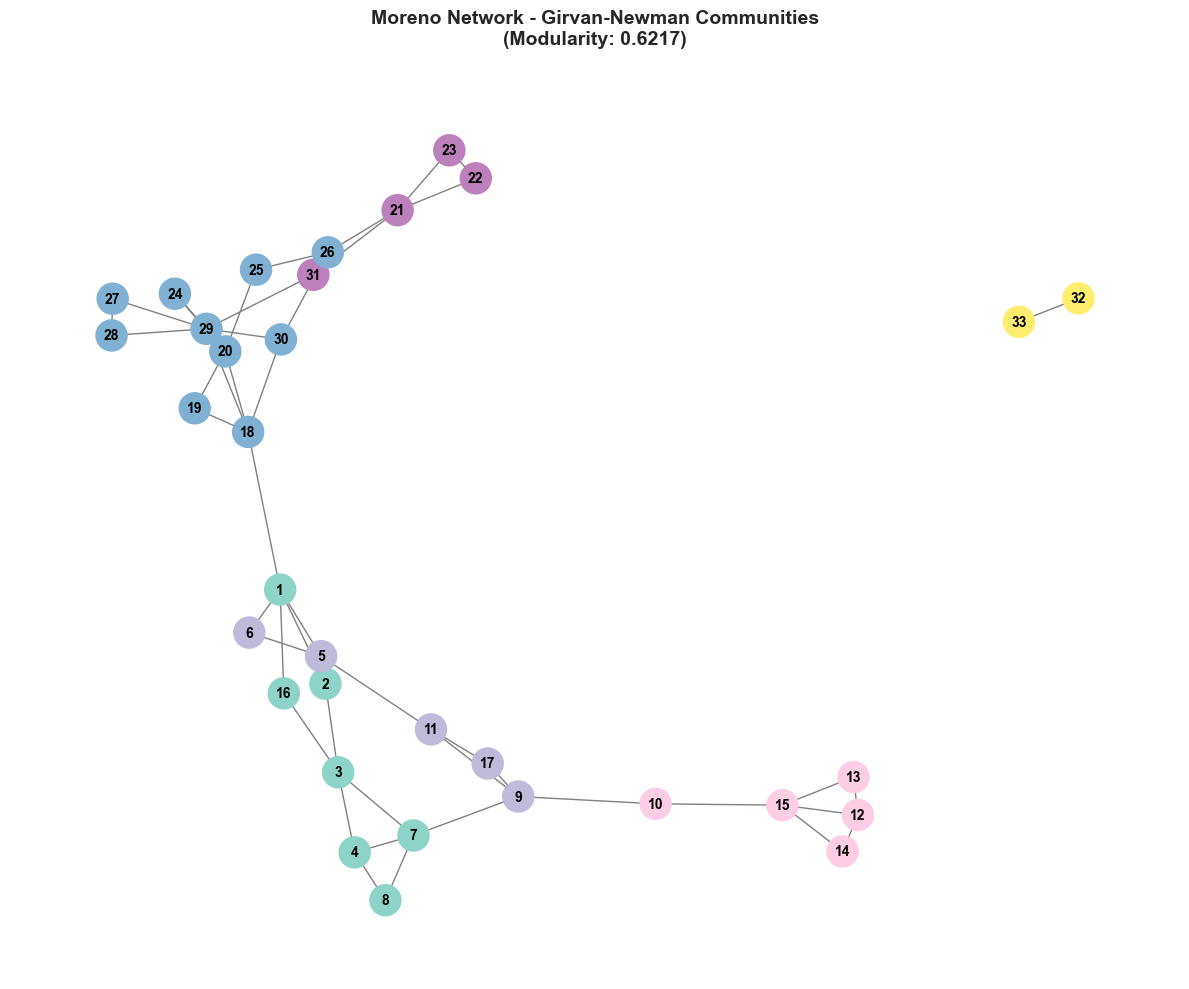

In [51]:
# Visualize communities detected by Girvan-Newman
fig, ax = plt.subplots(figsize=(12, 10))

# Color nodes by detected community
node_colors_comm = [membership_dict[node] for node in G_moreno.nodes()]

# Use spring layout
pos_moreno = nx.spring_layout(G_moreno, seed=42)

# Draw network
nx.draw_networkx(G_moreno, pos_moreno,
                 node_color=node_colors_comm,
                 cmap='Set3',
                 node_size=500,
                 with_labels=True,
                 font_size=10,
                 font_weight='bold',
                 edge_color='gray',
                 ax=ax)

ax.set_title(f"Moreno Network - Girvan-Newman Communities\n(Modularity: {best_modularity:.4f})",
             fontsize=14, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

##### Comparing Clustering Algorithms

Several algorithms can be used for community detection, and their results can be compared both visually and statistically. Clustering is similar to multiclass classification and can be evaluated using metrics like **modularity** (higher is better).

**Key Points:**
- Different algorithms may find different community structures
- Modularity is a common metric for comparing clustering quality
- Values above 0.3 typically indicate significant community structure
- The "best" algorithm depends on your specific network and goals

### Homophily

#### Data and Network Creation

Assume we have a group of 10 business engineering students working on a group project. Some of them follow **Data Analytics (DA)** and the others **Operations Research (OR)**. They all belong to one of these two groups: DA or OR.

These students sometimes collaborate when working on their group project, forming a network where two students are connected if they are currently working together.

As a result, we have **three types of edges** in the network:
- **'dd'**: edges connecting two DA students
- **'oo'**: edges connecting two OR students  
- **'do'**: edges connecting a DA and OR student

In [61]:
# Create student data
names = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
master = ['DA'] * 6 + ['OR'] * 4
students = pd.DataFrame({'name': names, 'master': master})

# Create network edges
students_network = pd.DataFrame({
    'from': ['A', 'A', 'A', 'A', 'B', 'B', 'C', 'C', 'D', 'D', 'D', 'E', 'F', 'F', 'G', 'G', 'H', 'H', 'I'],
    'to': ['B', 'C', 'D', 'E', 'C', 'D', 'D', 'G', 'E', 'F', 'G', 'F', 'G', 'I', 'I', 'H', 'I', 'J', 'J'],
    'label': ['dd'] * 7 + ['do', 'dd', 'dd', 'do', 'dd', 'do', 'do'] + ['oo'] * 5
})

print("Student Information:")
print(students)
print("\nStudent Network (Collaborations):")
print(students_network)

Student Information:
  name master
0    A     DA
1    B     DA
2    C     DA
3    D     DA
4    E     DA
5    F     DA
6    G     OR
7    H     OR
8    I     OR
9    J     OR

Student Network (Collaborations):
   from to label
0     A  B    dd
1     A  C    dd
2     A  D    dd
3     A  E    dd
4     B  C    dd
5     B  D    dd
6     C  D    dd
7     C  G    do
8     D  E    dd
9     D  F    dd
10    D  G    do
11    E  F    dd
12    F  G    do
13    F  I    do
14    G  I    oo
15    G  H    oo
16    H  I    oo
17    H  J    oo
18    I  J    oo


#### Network Plotting

Now we'll visualize the student collaboration network to see the homophily patterns. We'll use different colors for nodes (based on student program) and edges (based on relationship type).

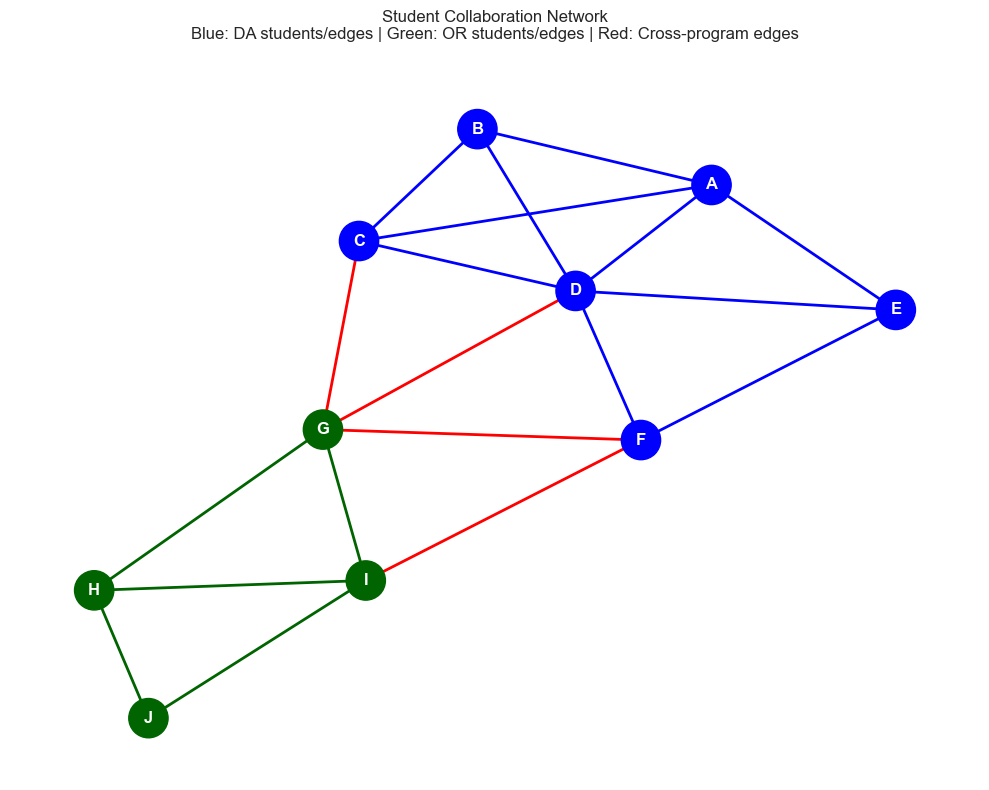


Observation:
- Blue nodes represent DA students, green nodes represent OR students
- Blue edges connect two DA students (dd)
- Green edges connect two OR students (oo)
- Red edges connect DA and OR students (do) - these are cross-label edges
- DA students tend to collaborate with each other, as do OR students
- There are fewer edges between the two student groups (homophily effect)


In [62]:
# Create network from student data
g_students = nx.from_pandas_edgelist(students_network, source='from', target='to', 
                                      edge_attr='label', create_using=nx.Graph())

# Add master program as node attribute
master_dict = dict(zip(students['name'], students['master']))
nx.set_node_attributes(g_students, master_dict, 'master')

# Define colors for nodes (based on master program)
node_colors_students = ['blue' if g_students.nodes[node]['master'] == 'DA' else 'darkgreen' 
                        for node in g_students.nodes()]

# Define colors for edges (based on label)
edge_colors_students = []
for u, v in g_students.edges():
    label = g_students[u][v]['label']
    if label == 'dd':
        edge_colors_students.append('blue')
    elif label == 'oo':
        edge_colors_students.append('darkgreen')
    else:  # 'do'
        edge_colors_students.append('red')

# Create visualization
plt.figure(figsize=(10, 8))
pos_students = nx.spring_layout(g_students, seed=42)

nx.draw_networkx(g_students, pos_students,
                 node_color=node_colors_students,
                 edge_color=edge_colors_students,
                 node_size=800,
                 width=2,
                 with_labels=True,
                 font_color='white',
                 font_weight='bold')

plt.title('Student Collaboration Network\nBlue: DA students/edges | Green: OR students/edges | Red: Cross-program edges',
          fontsize=12, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

print("\nObservation:")
print("- Blue nodes represent DA students, green nodes represent OR students")
print("- Blue edges connect two DA students (dd)")
print("- Green edges connect two OR students (oo)")
print("- Red edges connect DA and OR students (do) - these are cross-label edges")
print("- DA students tend to collaborate with each other, as do OR students")
print("- There are fewer edges between the two student groups (homophily effect)")

#### Network Properties

Before we can calculate dyadicity and heterophilicity, we first need to compute some foundational network properties. First, we need to calculate the number of nodes in each group and the number of edges in each group.

##### Number of Nodes

In [63]:
N = g_students.number_of_nodes()
n_da = sum(1 for node in g_students.nodes() if g_students.nodes[node]['master'] == 'DA')
n_or = sum(1 for node in g_students.nodes() if g_students.nodes[node]['master'] == 'OR')

print(f"Total nodes (N): {N}")
print(f"DA students (n_da): {n_da}")
print(f"OR students (n_or): {n_or}")

Total nodes (N): 10
DA students (n_da): 6
OR students (n_or): 4


##### Number of Edges

In [64]:
M = g_students.number_of_edges()
m_dd = sum(1 for u, v in g_students.edges() if g_students[u][v]['label'] == 'dd')
m_oo = sum(1 for u, v in g_students.edges() if g_students[u][v]['label'] == 'oo')
m_do = sum(1 for u, v in g_students.edges() if g_students[u][v]['label'] == 'do')

print(f"Total edges (M): {M}")
print(f"DD edges (m_dd): {m_dd}")
print(f"OO edges (m_oo): {m_oo}")
print(f"DO edges (m_do): {m_do}")

Total edges (M): 19
DD edges (m_dd): 10
OO edges (m_oo): 5
DO edges (m_do): 4


##### Connectedness

The **connectedness** of the network is the probability of two nodes being connected. It is obtained by dividing the actual number of edges (M) by the maximum possible number of edges in an undirected network.

**Formula**: 
$$p = \frac{2M}{N(N-1)}$$

Note that this is the same as the network density:

In [65]:
p = (2 * M) / (N * (N - 1))
print(f"Connectedness (p): {p:.4f}")
print(f"Network density: {nx.density(g_students):.4f}")

Connectedness (p): 0.4222
Network density: 0.4222


#### Heterophilicity

**Heterophilicity** is a measure of how diverse the connections are in a network. It quantifies the tendency of nodes to connect with nodes of different types (cross-label edges).

**Definition**: Heterophilicity (H) is the ratio between the actual number of cross-label edges and the expected number of such edges in a random network.

**Formula**:
$$H = \frac{m_{do}}{\bar{m}_{do}}$$

where:
- $m_{do}$ = actual number of cross-label edges (DA-OR connections)
- $\bar{m}_{do}$ = expected number of cross-label edges = $n_{da} \times n_{or} \times p$

**Interpretation**:
- **H < 1**: Fewer cross-label edges than expected (homophily - preference for similar connections)
- **H = 1**: Cross-label edges as expected in random network
- **H > 1**: More cross-label edges than expected (heterophily - preference for diverse connections)

In [66]:
bar_m_do = n_da*n_or*p
H = m_do/bar_m_do
print(H)

0.39473684210526316


#### Dyadicity

**Dyadicity** measures the tendency of nodes to form connections with similar nodes (same-label edges). It is the ratio between the actual number of same-label edges and the expected number of such edges.

**Formulas**:

For DA students:
$$D_{dd} = \frac{m_{dd}}{\bar{m}_{dd}}$$

where $\bar{m}_{dd} = \frac{n_da \times (n_da - 1)}{2} \times p$

For OR students:
$$D_{oo} = \frac{m_{oo}}{\bar{m}_{oo}}$$

where $\bar{m}_{oo} = \frac{n_or \times (n_or - 1)}{2} \times p$

**Interpretation**:
- **D > 1**: More same-label edges than expected (homophily)
- **D = 1**: Same-label edges as expected in random network
- **D < 1**: Fewer same-label edges than expected

In [67]:
# Using the DA/OR student network properties from Section 6.3
# (N, n_da, n_or, M, m_dd, m_oo, m_do, and p should already be calculated)

# Calculate dyadicity for DA students
bar_m_dd = (n_da * (n_da - 1) / 2) * p
D_dd = m_dd / bar_m_dd

print(f"DA students - Actual same-label edges (m_dd): {m_dd}")
print(f"DA students - Expected same-label edges (bar_m_dd): {bar_m_dd:.4f}")
print(f"DA students - Dyadicity (D_dd): {D_dd:.4f}")

# Calculate dyadicity for OR students
bar_m_oo = (n_or * (n_or - 1) / 2) * p
D_oo = m_oo / bar_m_oo

print(f"\nOR students - Actual same-label edges (m_oo): {m_oo}")
print(f"OR students - Expected same-label edges (bar_m_oo): {bar_m_oo:.4f}")
print(f"OR students - Dyadicity (D_oo): {D_oo:.4f}")

DA students - Actual same-label edges (m_dd): 10
DA students - Expected same-label edges (bar_m_dd): 6.3333
DA students - Dyadicity (D_dd): 1.5789

OR students - Actual same-label edges (m_oo): 5
OR students - Expected same-label edges (bar_m_oo): 2.5333
OR students - Dyadicity (D_oo): 1.9737


## Social Network Learning

In this section, we will explore how to infer the behavior of nodes in a social network based on the behavior of their neighboring nodes. This process is known as **social network learning** or **relational learning**.

Social network learning leverages the principle that connected nodes in a network often share similar attributes or behaviors. By examining the characteristics of a node's neighbors, we can make predictions about unknown attributes of that node.

#### Plotting

##### Creating a Bank Customer Network

Consider a network of customers of a bank. Each edge represents a connection between two customers (e.g., they are friends or business partners):

In [68]:
# Create the bank customer network
bank_edges = pd.DataFrame({
    'from': ['A', 'A', 'A', 'A', 'B', 'B', 'C', 'C', 'D', 'D', 'D', 'E',
             'F', 'F', 'G', 'G', 'H', 'H', 'I'],
    'to': ['B', 'C', 'D', 'E', 'C', 'D', 'D', 'G', 'E', 'F', 'G', 'F',
           'G', 'I', 'I', 'H', 'I', 'J', 'J']
})

print(bank_edges.to_string(index=False))

from to
   A  B
   A  C
   A  D
   A  E
   B  C
   B  D
   C  D
   C  G
   D  E
   D  F
   D  G
   E  F
   F  G
   F  I
   G  I
   G  H
   H  I
   H  J
   I  J


##### Plotting the Network

We can convert this dataframe into a NetworkX graph object:

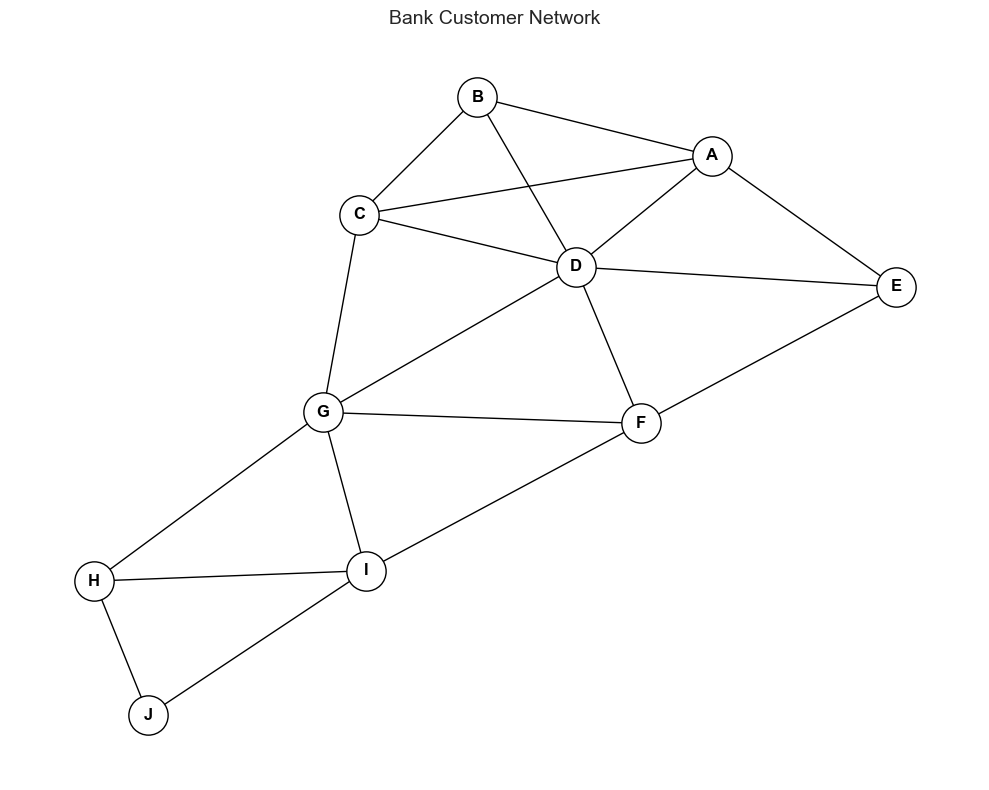

In [69]:
# Create graph from edge list
g_bank = nx.from_pandas_edgelist(bank_edges, source='from', target='to')

# Basic visualization
plt.figure(figsize=(10, 8), dpi=100)
pos_bank = nx.spring_layout(g_bank, seed=42)
nx.draw_networkx(g_bank, pos_bank, node_color='white', 
                 edgecolors='black', node_size=800,
                 font_size=12, font_weight='bold')
plt.title('Bank Customer Network', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

##### Adding Node Attributes: Churn Behavior

Node attributes can be used to add additional information to the nodes in the network. For example, we can add a **churn** attribute to indicate whether a customer has churned (left the bank):

- `1` = customer has churned
- `0` = customer has not churned  
- `None` (or missing) = unknown churn status

Each churn label can have its own color on the graph to visualize patterns:

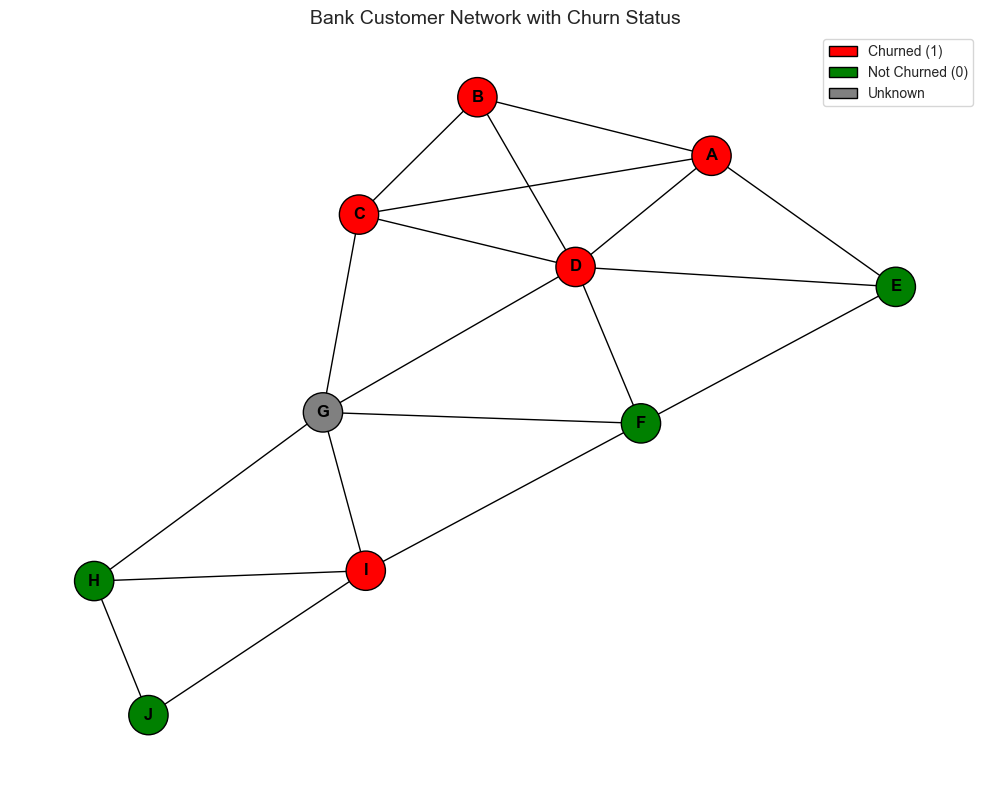

In [70]:
# Add churn attributes to nodes
churn_labels = {
    'A': 1, 'B': 1, 'C': 1, 'D': 1,  # Churned customers
    'E': 0, 'F': 0, 'H': 0, 'J': 0,  # Non-churned customers
    'G': None, 'I': 1                # G is unknown, I churned
}

# Set node attributes
nx.set_node_attributes(g_bank, churn_labels, 'churn')

# Create color mapping based on churn status
node_colors_bank = []
for node in g_bank.nodes():
    churn_status = g_bank.nodes[node].get('churn')
    if churn_status is None:
        node_colors_bank.append('grey')  # Unknown
    elif churn_status == 1:
        node_colors_bank.append('red')   # Churned
    else:
        node_colors_bank.append('green') # Not churned

# Visualize with colors
plt.figure(figsize=(10, 8), dpi=100)
nx.draw_networkx(g_bank, pos_bank, node_color=node_colors_bank,
                 edgecolors='black', node_size=800,
                 font_size=12, font_weight='bold')
plt.title('Bank Customer Network with Churn Status', fontsize=14)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', edgecolor='black', label='Churned (1)'),
    Patch(facecolor='green', edgecolor='black', label='Not Churned (0)'),
    Patch(facecolor='grey', edgecolor='black', label='Unknown')
]
plt.legend(handles=legend_elements, loc='upper right')
plt.axis('off')
plt.tight_layout()
plt.show()

#### Relational Neighbor Classifier

In this section, we will explore how to use the connections between different nodes in a social network to predict whether a customer will churn or not. This process is known as **relational neighbor classification**.

The relational neighbor classifier uses the principle that a node's attribute can be predicted based on the attributes of its neighbors. In our case, we'll predict churn behavior by examining the churn status of connected customers.

##### Getting the Adjacency Matrix

First, we need to get the adjacency matrix of the bank network to identify neighbors:

In [71]:
# Get adjacency matrix
adjacency_bank = nx.to_numpy_array(g_bank)

# Create a dataframe for better visualization
adjacency_bank_df = pd.DataFrame(
    adjacency_bank,
    index=sorted(g_bank.nodes()),
    columns=sorted(g_bank.nodes())
).astype(int)

print("Adjacency Matrix:")
print(adjacency_bank_df)

Adjacency Matrix:
   A  B  C  D  E  F  G  H  I  J
A  0  1  1  1  1  0  0  0  0  0
B  1  0  1  1  0  0  0  0  0  0
C  1  1  0  1  0  1  0  0  0  0
D  1  1  1  0  1  1  1  0  0  0
E  1  0  0  1  0  0  1  0  0  0
F  0  0  1  1  0  0  1  1  1  0
G  0  0  0  1  1  1  0  1  0  0
H  0  0  0  0  0  1  1  0  1  1
I  0  0  0  0  0  1  0  1  0  1
J  0  0  0  0  0  0  0  1  1  0


##### Calculating Neighbor Churn Counts

For each node, we count how many of its neighbors have churned versus not churned:

In [72]:
# Initialize arrays to store neighbor counts
nodes_list = sorted(g_bank.nodes())
n_nodes_bank = len(nodes_list)

churn_neighbors = np.zeros(n_nodes_bank)
nonchurn_neighbors = np.zeros(n_nodes_bank)

# For each node, count churning and non-churning neighbors
for i, node in enumerate(nodes_list):
    neighbors = list(g_bank.neighbors(node))
    
    for neighbor in neighbors:
        churn_value = g_bank.nodes[neighbor].get('churn')
        
        if churn_value == 1:
            churn_neighbors[i] += 1
        elif churn_value == 0:
            nonchurn_neighbors[i] += 1
        # Note: None values (unknown) are not counted

print("Churning neighbors per node:")
print(dict(zip(nodes_list, churn_neighbors.astype(int))))
print("\nNon-churning neighbors per node:")
print(dict(zip(nodes_list, nonchurn_neighbors.astype(int))))

Churning neighbors per node:
{'A': np.int64(3), 'B': np.int64(3), 'C': np.int64(3), 'D': np.int64(3), 'E': np.int64(2), 'F': np.int64(2), 'G': np.int64(3), 'H': np.int64(1), 'I': np.int64(0), 'J': np.int64(1)}

Non-churning neighbors per node:
{'A': np.int64(1), 'B': np.int64(0), 'C': np.int64(0), 'D': np.int64(2), 'E': np.int64(1), 'F': np.int64(1), 'G': np.int64(2), 'H': np.int64(1), 'I': np.int64(3), 'J': np.int64(1)}


##### Calculating Churn Probability

Next, we calculate the probability of churn for each node based on the proportion of churning neighbors:

In [73]:
# Calculate probability of churn
total_neighbors = churn_neighbors + nonchurn_neighbors
prob_churn = np.divide(churn_neighbors, total_neighbors, 
                       where=total_neighbors > 0, 
                       out=np.zeros_like(churn_neighbors))

# Create results dataframe
churn_results = pd.DataFrame({
    'node': nodes_list,
    'prob_churn': prob_churn
})

print("Probability of Churn by Node:")
print(churn_results.to_string(index=False))

Probability of Churn by Node:
node  prob_churn
   A    0.750000
   B    1.000000
   C    1.000000
   D    0.600000
   E    0.666667
   F    0.666667
   G    0.600000
   H    0.500000
   I    0.000000
   J    0.500000


##### Calculating Non-Churn Probability

Similarly, we can calculate the probability of not churning:

In [74]:
# Calculate probability of non-churn
prob_nonchurn = np.divide(nonchurn_neighbors, total_neighbors,
                          where=total_neighbors > 0,
                          out=np.zeros_like(nonchurn_neighbors))

# Verify that probabilities sum to 1
print("Probability of Non-Churn by Node:")
print(prob_nonchurn)
print("\nVerification - Sum of probabilities (should be 1.0 for each node):")
print(prob_churn + prob_nonchurn)

Probability of Non-Churn by Node:
[0.25       0.         0.         0.4        0.33333333 0.33333333
 0.4        0.5        1.         0.5       ]

Verification - Sum of probabilities (should be 1.0 for each node):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


The sum of `prob_churn` and `prob_nonchurn` for each node should equal 1.0 (or 0.0 for nodes with no labeled neighbors).

#### Probabilistic Relational Neighbor Classifier

In this section, we will extend the relational neighbor classifier by incorporating probabilistic predictions from a machine learning model (e.g., logistic regression). This process is known as **probabilistic relational neighbor classification (PRN)**.

Instead of using binary labels (0 or 1), the PRN classifier uses probability values that represent the likelihood of each class. This allows for more nuanced predictions that take into account the uncertainty in the model's predictions.

##### Using Probabilistic Predictions

Suppose we have churn probabilities from a logistic regression model for each customer in the bank network:

In [75]:
# Probabilistic predictions from a logistic regression model
# These represent P(churn=1) for each customer
preds_bank = np.array([0.75, 0.50, 0.3333333, 0.80, 0.20, 0.50, 0.50, 0.6666667, 0.75, 0.00])

print("Churn Probabilities from Logistic Regression:")
for node, prob in zip(nodes_list, preds_bank):
    print(f"  {node}: {prob:.4f}")

Churn Probabilities from Logistic Regression:
  A: 0.7500
  B: 0.5000
  C: 0.3333
  D: 0.8000
  E: 0.2000
  F: 0.5000
  G: 0.5000
  H: 0.6667
  I: 0.7500
  J: 0.0000


##### Updating Node Attributes

We update the churn attribute with these probabilistic values:

In [76]:
# Update churn attributes with probabilistic values
churn_probs = {node: prob for node, prob in zip(nodes_list, preds_bank)}
nx.set_node_attributes(g_bank, churn_probs, 'churn')

print("Updated churn probabilities in network:")
for node in nodes_list:
    print(f"  {node}: {g_bank.nodes[node]['churn']:.4f}")

Updated churn probabilities in network:
  A: 0.7500
  B: 0.5000
  C: 0.3333
  D: 0.8000
  E: 0.2000
  F: 0.5000
  G: 0.5000
  H: 0.6667
  I: 0.7500
  J: 0.0000


##### Calculating Probabilistic Neighbor Counts

Now we calculate the sum of churn probabilities for each node's neighbors. Instead of counting binary labels, we sum the probability values:

In [77]:
# Initialize arrays for probabilistic neighbor sums
churn_neighbors_upt = np.zeros(n_nodes_bank)
nonchurn_neighbors_upt = np.zeros(n_nodes_bank)

# For each node, sum the churn probabilities of neighbors
for i, node in enumerate(nodes_list):
    neighbors = list(g_bank.neighbors(node))
    
    for neighbor in neighbors:
        churn_prob = g_bank.nodes[neighbor]['churn']
        # Churn probability
        churn_neighbors_upt[i] += churn_prob
        # Non-churn probability (complement)
        nonchurn_neighbors_upt[i] += (1 - churn_prob)

print("Sum of churning neighbor probabilities:")
print(dict(zip(nodes_list, churn_neighbors_upt)))
print("\nSum of non-churning neighbor probabilities:")
print(dict(zip(nodes_list, nonchurn_neighbors_upt)))

Sum of churning neighbor probabilities:
{'A': np.float64(1.8333333), 'B': np.float64(1.8833333), 'C': np.float64(2.55), 'D': np.float64(2.7833333), 'E': np.float64(2.05), 'F': np.float64(2.25), 'G': np.float64(3.0500000000000003), 'H': np.float64(1.25), 'I': np.float64(1.6666667), 'J': np.float64(1.4166667)}

Sum of non-churning neighbor probabilities:
{'A': np.float64(2.1666667), 'B': np.float64(1.1166667), 'C': np.float64(1.45), 'D': np.float64(3.2166667), 'E': np.float64(0.95), 'F': np.float64(1.75), 'G': np.float64(1.95), 'H': np.float64(1.75), 'I': np.float64(2.3333333), 'J': np.float64(0.5833333)}


##### Calculating PRN Churn Probability

The updated probability of churn is calculated as:

In [78]:
# Calculate updated probability of churn
total_neighbors_upt = churn_neighbors_upt + nonchurn_neighbors_upt
prob_churn_upt = np.divide(churn_neighbors_upt, total_neighbors_upt,
                           where=total_neighbors_upt > 0,
                           out=np.zeros_like(churn_neighbors_upt))

# Create results dataframe
prn_results = pd.DataFrame({
    'Node': nodes_list,
    'PRN': prob_churn_upt
})

print("Probabilistic Relational Neighbor (PRN) Churn Probability:")
print(prn_results.to_string(index=False))

Probabilistic Relational Neighbor (PRN) Churn Probability:
Node      PRN
   A 0.458333
   B 0.627778
   C 0.637500
   D 0.463889
   E 0.683333
   F 0.562500
   G 0.610000
   H 0.416667
   I 0.416667
   J 0.708333


**Key Insight:** The PRN approach provides more refined predictions by incorporating the model's confidence (probabilities) rather than hard binary decisions. A node surrounded by neighbors with high churn probabilities will itself have a high PRN churn probability.

## Data Collection

### Web Scraping

In this section, we will learn how to scrape data from webpages using **BeautifulSoup** and **Requests** in Python. Web scraping is a method used to extract data from websites programmatically. This can be done by parsing the HTML structure of web pages and extracting specific elements.

**What is Web Scraping?**

Web scraping allows you to automatically collect data from websites that don't offer APIs. While APIs provide structured access to data (like we will see with Mastodon and Bluesky), many websites only present information in HTML format meant for human browsers.

**Resources:**
- BeautifulSoup Documentation: [beautiful-soup-4.readthedocs.io](https://beautiful-soup-4.readthedocs.io/)
- Practice websites: [scrapethissite.com](https://www.scrapethissite.com/)
- Learn about robots.txt: [https://developers.google.com/search/docs/crawling-indexing/robots/intro](https://developers.google.com/search/docs/crawling-indexing/robots/intro)

#### Important: Ethical and Legal Considerations

Before scraping any website, you should **always** check two things:

1. **`robots.txt` file**: This file tells automated bots which parts of a website can or cannot be accessed. You can find it by adding `/robots.txt` to the website's root URL (e.g., `https://example.com/robots.txt`).

2. **Terms of Service (ToS)**: Review the website's terms of service to ensure web scraping is permitted. Some websites explicitly prohibit automated data collection (e.g, Facebook, X,  etc.). 

**Understanding robots.txt**

The `robots.txt` file contains directives for web crawlers:
- `User-agent`: Specifies which bot the rules apply to (`*` means all bots)
- `Disallow`: Paths that should not be accessed
- `Allow`: Paths that can be accessed (overrides Disallow)
- `Crawl-delay`: Minimum time (in seconds) to wait between requests

**Example: Checking Reddit's robots.txt**

Let's look at Reddit's robots.txt file: [https://www.reddit.com/robots.txt](https://www.reddit.com/robots.txt)

The actual content (as of January 2026):
```
# Welcome to Reddit's robots.txt
# Reddit believes in an open internet, but not the misuse of public content.
# See Reddit's Public Content Policy for access and use restrictions.
# See r/reddit4researchers for details on research and non-commercial use.

User-agent: *
Disallow: /
```

This means:
- **Reddit blocks ALL automated scraping** of their entire website (`Disallow: /`)
- Reddit directs users to their official API and research programs instead
- Violating this could result in IP bans or legal action

**Key Takeaway:** Many major platforms (Reddit, X/Twitter, Facebook, LinkedIn) now prohibit web scraping entirely. Always check the current `robots.txt` before proceeding, as policies change frequently.

**Best Practices:**
- Always respect `robots.txt` directives
- Implement reasonable delays between requests (e.g., 1-2 seconds)
- Stop if you receive Too Many Requests errors
- Consider using official APIs when available

#### BeatifulSoup and Requests

##### Installing Required Libraries

First, we need to install the web scraping libraries if they're not already installed:

In [ ]:
# Install beautifulsoup4, requests, and lxml if needed

# Import libraries
import requests
from bs4 import BeautifulSoup
import re

print("BeautifulSoup, Requests, and parsing libraries are ready!")

BeautifulSoup, Requests, and parsing libraries are ready!


##### Defining the URL

The first step in web scraping is to define the URL of the webpage you want to scrape. In this exercise, we will scrape a practice website designed for learning web scraping:

In [81]:
# Define the URL to scrape
url = "https://www.scrapethissite.com/pages/simple/"
print(f"Target URL: {url}")

Target URL: https://www.scrapethissite.com/pages/simple/


##### Downloading and Parsing the HTML

After defining the URL, we use `requests.get()` to download the webpage and `BeautifulSoup` to parse the HTML:

In [82]:
# Download the webpage
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    print("✓ Successfully downloaded the webpage")
    
    # Parse the HTML content
    soup = BeautifulSoup(response.content, 'html.parser')
    print(f"✓ Parsed HTML document with {len(soup.find_all())} total elements")
else:
    print(f"✗ Failed to download webpage. Status code: {response.status_code}")

✓ Successfully downloaded the webpage
✓ Parsed HTML document with 3659 total elements


##### Finding Elements with CSS Selectors

To extract specific data, we need to identify the HTML elements containing that data. We can use CSS selectors to target elements. In most web browsers, we can use browser developer tools:

1. **Right-click** on an element on the webpage
2. Select **"Inspect"** or **"Inspect Element"**
3. Look at the HTML structure and identify CSS classes or IDs

For the country names on this page, they use the CSS class `.country-name`:

In [86]:
# Find all elements with the class 'country-name'
# We use .select() with CSS selectors instead of .find_all() because:
# - .select('.country-name') is more concise than find_all('h3', class_='country-name')
# - CSS selectors are familiar to anyone who knows web development
# - .select() allows complex queries like '.parent > .child', '[attribute="value"]'
# 
# Alternative with find_all() would be:
# country_elements = soup.find_all('h3', class_='country-name')
# Both work equally well! Choose based on your preference.
country_elements = soup.select('.country-name')

print(f"Found {len(country_elements)} country name elements")

# Preview the first element
if country_elements:
    print(f"\nFirst element HTML:")
    print(country_elements[0])

Found 250 country name elements

First element HTML:
<h3 class="country-name">
<i class="flag-icon flag-icon-ad"></i>
                            Andorra
                        </h3>


##### Extracting Text Content

Now we extract the text from each element and clean it up:

In [84]:
# Extract text from each element
country_names_raw = [element.get_text() for element in country_elements]

print("Raw country names (first 5):")
for i, name in enumerate(country_names_raw[:5], 1):
    print(f"  {i}. '{name}'")

Raw country names (first 5):
  1. '

                            Andorra
                        '
  2. '

                            United Arab Emirates
                        '
  3. '

                            Afghanistan
                        '
  4. '

                            Antigua and Barbuda
                        '
  5. '

                            Anguilla
                        '


Notice the raw text contains leading/trailing whitespace and newlines. We can clean this using `.strip()`:

In [85]:
# Clean the text by stripping whitespace
country_names = [name.strip() for name in country_names_raw]

print(f"Cleaned country names ({len(country_names)} total):")
print(country_names[:16])  # Show first 16 countries

Cleaned country names (250 total):
['Andorra', 'United Arab Emirates', 'Afghanistan', 'Antigua and Barbuda', 'Anguilla', 'Albania', 'Armenia', 'Angola', 'Antarctica', 'Argentina', 'American Samoa', 'Austria', 'Australia', 'Aruba', 'Åland', 'Azerbaijan']


#### Scraping Tables

Many websites organize data in HTML tables. Python's `pandas` library provides a convenient function `read_html()` that can automatically extract tables from web pages. This is much simpler than manually parsing table structure with BeautifulSoup!

##### Defining the URL

We will scrape a table of hockey team statistics from the scrapethissite.com forms page:

In [87]:
# Define the URL for the hockey teams table
url = "https://www.scrapethissite.com/pages/forms/"
print(f"Target URL: {url}")

Target URL: https://www.scrapethissite.com/pages/forms/


##### Downloading and Parsing the HTML Table

We can use pandas' `read_html()` function, which is specifically designed for extracting tables from HTML.

In [91]:
# Read all tables from the webpage
# pandas.read_html() returns a list of all tables found
tables = pd.read_html(url)

print(f"Found {len(tables)} table(s) on the page")

# Get the first (and only) table
hockey_teams = tables[0]

# Display the first few rows
print("\nFirst 5 rows of the hockey teams data:")
hockey_teams.head(5)

Found 1 table(s) on the page

First 5 rows of the hockey teams data:


,Team Name,Year,Wins,Losses,OT Losses,Win %,Goals For (GF),Goals Against (GA),+ / -
0,Boston Bruins,1990,44,24,NaN,0.550,299,264,35
1,Buffalo Sabres,1990,31,30,NaN,0.388,292,278,14
2,Calgary Flames,1990,46,26,NaN,0.575,344,263,81
3,Chicago Blackhawks,1990,49,23,NaN,0.613,284,211,73
4,Detroit Red Wings,1990,34,38,NaN,0.425,273,298,-25


##### Scraping More Entries

By default, the webpage only shows 25 entries per page. To scrape more entries, we can modify the URL to include a `per_page` parameter. The website allows up to 100 entries per page:

In [92]:
# Modify the URL to get 100 entries per page
url_100 = "https://www.scrapethissite.com/pages/forms/?per_page=100"

# Read the table again
hockey_teams = pd.read_html(url_100)[0]

print(f"Number of rows scraped: {len(hockey_teams)}")
print(f"Columns: {list(hockey_teams.columns)}")

Number of rows scraped: 100
Columns: ['Team Name', 'Year', 'Wins', 'Losses', 'OT Losses', 'Win %', 'Goals For (GF)', 'Goals Against (GA)', '+ / -']


#### More Web Scraping Techniques

In this section, we'll explore additional methods for extracting data from websites and discuss best practices for web scraping.

##### Quick Copy-Paste Solution: Reading from Clipboard

Sometimes you just need a quick solution to get data into Python. You can copy tabular data from a website and read it directly from your clipboard using pandas:

In [95]:
# Quick and dirty solution: read from clipboard
# Works on both Windows and Mac

# After copying a table from a website, run:
# clipboard_data = pd.read_clipboard()

# Example: Copy a table from any website, then run the above command
# The data will be automatically parsed into a DataFrame

print("To use clipboard reading:")
print("1. Copy a table from a website (Ctrl+C or Cmd+C)")
print("2. Run: clipboard_data = pd.read_clipboard()")
print("3. Your data is now in a DataFrame!")

To use clipboard reading:
1. Copy a table from a website (Ctrl+C or Cmd+C)
2. Run: clipboard_data = pd.read_clipboard()
3. Your data is now in a DataFrame!


#### Advanced Web Scraping Techniques

If you wish to dive deeper into web scraping beyond what we've covered, here are additional topics to explore:

##### HTML and CSS Structure**
   - Understanding the Document Object Model (DOM)
   - How HTML elements are structured hierarchically
   - CSS classes and IDs for targeting elements

##### XPath and CSS Selectors
   - **CSS Selectors** (what we've been using):
     - `.classname` - selects elements by class
     - `#idname` - selects elements by ID
     - `tag.class` - selects specific tags with a class
     - `parent > child` - direct child selector
   - **XPath** (alternative powerful selector language):
     - `//div[@class='content']` - finds div with class
     - `//a[contains(text(), 'Next')]` - finds links containing text

In [96]:
# Example: More advanced CSS selectors
example_html = """
<html>
    <div class="container">
        <article class="post featured">
            <h2>Featured Post</h2>
            <p class="author">By John Doe</p>
            <p class="content">This is the main content.</p>
        </article>
        <article class="post">
            <h2>Regular Post</h2>
            <p class="author">By Jane Smith</p>
        </article>
    </div>
</html>
"""

soup = BeautifulSoup(example_html, 'html.parser')

# Different selector techniques:
print("1. Select by class:")
print(f"   Articles: {len(soup.select('.post'))} found")

print("\n2. Select with multiple classes:")
print(f"   Featured posts: {len(soup.select('.post.featured'))} found")

print("\n3. Select by hierarchy (direct child):")
print(f"   Container > Article: {len(soup.select('.container > article'))} found")

print("\n4. Select by attribute:")
featured = soup.find('article', class_='post featured')
if featured:
    print(f"   Featured title: {featured.h2.get_text()}")

print("\n5. Select with complex criteria:")
authors = [p.get_text() for p in soup.select('article p.author')]
print(f"   Authors: {authors}")

1. Select by class:
   Articles: 2 found

2. Select with multiple classes:
   Featured posts: 1 found

3. Select by hierarchy (direct child):
   Container > Article: 2 found

4. Select by attribute:
   Featured title: Featured Post

5. Select with complex criteria:
   Authors: ['By John Doe', 'By Jane Smith']


#### Recommended Resources

Here are some excellent resources to continue your web scraping journey:

**Python-Specific Resources:**
- [BeautifulSoup Documentation](https://www.crummy.com/software/BeautifulSoup/bs4/doc/)
- [Real Python - Web Scraping Guide](https://realpython.com/python-web-scraping-practical-introduction/)
- [Scrapy Tutorial](https://docs.scrapy.org/en/latest/intro/tutorial.html) - for large-scale crawling
- [Selenium with Python](https://selenium-python.readthedocs.io/) - for JavaScript-heavy sites

**General Web Scraping Concepts:**
- [CSS Selectors Reference](https://www.w3schools.com/cssref/css_selectors.php)
- [XPath Tutorial](https://www.w3schools.com/xml/xpath_intro.asp)
- [HTTP Headers and User Agents](https://developer.mozilla.org/en-US/docs/Web/HTTP/Headers)

You now have the tools to extract data from static HTML pages and tables. In the next section, we'll explore how to collect data from social media platforms using APIs like Mastodon and Bluesky, which provide more structured and reliable access to social media data.

### Social Media: Decentralized Platforms

Decentralized platforms represent a shift toward open, federated social networks where no single entity controls the entire network. These platforms typically offer:
- **Open APIs** with no application review process
- **Transparent data access** policies
- **User control** over data and privacy
- **Federation** allowing communication between independent servers

We'll explore two major decentralized platforms: **Mastodon** (microblogging, part of the Fediverse) and **Bluesky** (using the AT Protocol).

#### Mastodon API

**Mastodon** is a decentralized social network - part of the "Fediverse" - that operates differently from traditional platforms like Twitter/X. Instead of one company owning all servers, Mastodon consists of thousands of independent servers (instances) that communicate with each other.

**Why Start with Mastodon?**
Mastodon represents an important shift toward open, decentralized social media platforms. Its API is:
- **Open**: No application review process needed
- **Well-documented**: Clear API structure  
- **Accessible**: Easy to get started with research access
- **Ethical**: Respects user privacy and platform independence

To collect and analyze data from Mastodon, we will use the `Mastodon.py` package, which is a Python wrapper around the Mastodon public API. This library simplifies authentication and data retrieval, allowing us to search for posts ("toots"), retrieve user information, and analyze timelines.

**Resources:**
- Mastodon Python Library: [Mastodon.py Documentation](https://mastodonpy.readthedocs.io/)
- Official Mastodon API: [GitHub Repository](https://github.com/mastodon/mastodon/)

In [97]:
# Install Mastodon.py if needed
# Uncomment the following line if you need to install:
# !pip install Mastodon.py

from mastodon import Mastodon
import time

print("Mastodon.py library is ready!")

Mastodon.py library is ready!


##### Authentication

To authenticate with Mastodon, there are two options:

**Option 1: Simple Access Token (We will use this method)**
1. Go to your instance (e.g., mastodon.social) → Preferences → Development
2. Create a new application with read permissions (the more permissions the better)
3. Copy your access token
4. Use it directly in the initialization code below

This is the simplest method and sufficient for most data collection purposes.

**Option 2: Full OAuth Flow**

The official [Mastodon.py documentation](https://mastodonpy.readthedocs.io/en/stable/index.html#) describes a complete OAuth flow that involves:
1. Registering your app with `Mastodon.create_app()`
2. Getting an authorization URL and requesting user permission
3. Exchanging the authorization code for an access token
4. Saving credentials to files for reuse

This method is more complex and typically used when building applications that need to act on behalf of users.

To keep your access token secure and separate from the code, we use a `config.py` file:

1. Copy the `config_template.py` file to create your own `mastodon_config.py`
2. Add your access token and instance URL to `mastodon_config.py`
3. The notebook will automatically load your credentials

**Why use a config file?**
- **Security**: Your token won't be visible in the notebook or accidentally shared
- **Privacy**: Each student uses their own credentials without seeing others' tokens

This is a best practice for handling sensitive credentials in any project!

In [98]:
# Initialize Mastodon client
# Load credentials from config file
try:
    from mastodon_config import MASTODON_ACCESS_TOKEN, MASTODON_API_BASE_URL
    mastodon = Mastodon(
        access_token=MASTODON_ACCESS_TOKEN,
        api_base_url=MASTODON_API_BASE_URL
    )
    print("✓ Connected to Mastodon successfully")
except ImportError:
    # Students should create their own config.py file with their credentials
    print("config.py not found. Please create a config.py file with:")
    print("MASTODON_ACCESS_TOKEN = 'your_token_here'")
    print("MASTODON_API_BASE_URL = 'https://your_instance.social'")

# Fallback: you can manually set credentials here
# mastodon = Mastodon(
#     access_token='YOUR_ACCESS_TOKEN_HERE',
#     api_base_url='https://mastodon.social'
# )

✓ Connected to Mastodon successfully


##### Searching for Posts by Hashtag

Hashtags are metadata tags that categorize content and make it discoverable to users interested in specific topics. We use `timeline_hashtag()` to search for toots containing a specific hashtag.

**Understanding Pagination:**

The Mastodon API limits each request to a maximum of 40 toots. To collect more data, we need to use **pagination** - fetching data in multiple batches:

1. **First request**: Get the 40 most recent toots
2. **Subsequent requests**: Get the next 40 older toots, and so on

**How to Implement:**

```python
# First batch
timeline = mastodon.timeline_hashtag(hashtag, limit=40)

# Get next batches - IMPORTANT: reassign the result!
timeline = mastodon.fetch_next(timeline)  # ← Updates timeline for next iteration
```

The key is **reassigning** the result back to `timeline`. This ensures `fetch_next()` knows where to continue from. Without reassignment, it will keep returning the same 40 toots.

The function `fetch_next()` automatically uses the `max_id` parameter internally to get older toots going backwards in time.

In [99]:
# Fetch toots by hashtag with pagination
hashtag = "photography"
max_toots = 200

print(f"Fetching toots for #{hashtag}...\n")

# Fetch first batch (most recent 40 toots)
timeline = mastodon.timeline_hashtag(hashtag, limit=40)
all_toots = list(timeline)
print(f"Batch 1: {len(all_toots)} toots")

# Fetch additional batches (each batch gets 40 older toots)
pages_needed = (max_toots // 40) - 1

for i in range(pages_needed):
    # Add small delay to avoid rate limiting
    time.sleep(0.5)
    
    # Get next batch - IMPORTANT: reassign to timeline
    timeline = mastodon.fetch_next(timeline)
    if timeline:
        all_toots.extend(timeline)
        print(f"Batch {i+2}: {len(timeline)} toots (total: {len(all_toots)})")
    else:
        print(f"Reached end of available data after {len(all_toots)} toots")
        break

# Convert to DataFrame
df_toots = pd.DataFrame(all_toots[:max_toots])
print(f"\n✓ Total retrieved: {len(df_toots)} toots")

Fetching toots for #photography...

Batch 1: 40 toots
Batch 2: 40 toots (total: 80)
Batch 3: 40 toots (total: 120)
Batch 4: 40 toots (total: 160)
Batch 5: 40 toots (total: 200)

✓ Total retrieved: 200 toots


##### Data Quality Check

Let's verify the quality of the collected data:
- **Unique IDs**: With proper pagination, each toot should have a unique ID
- **Retoots/boosts**: Shared posts that typically make up 40-60% of timeline content

In [100]:
# Check data quality
print("Data Quality Report")
print("=" * 50)
print(f"Total toots: {len(df_toots)}")
print(f"Unique IDs: {df_toots['id'].nunique()}")
print(f"Retoots/boosts: {df_toots['reblog'].notna().sum()} ({df_toots['reblog'].notna().sum() / len(df_toots) * 100:.1f}%)")

# Display basic DataFrame info
print(f"\nShape: {df_toots.shape}")
print(f"Columns: {list(df_toots.columns)[:10]}...")  # Show first 10 columns

Data Quality Report
Total toots: 200
Unique IDs: 200
Retoots/boosts: 0 (0.0%)

Shape: (200, 33)
Columns: ['id', 'uri', 'url', 'account', 'in_reply_to_id', 'in_reply_to_account_id', 'reblog', 'content', 'created_at', 'reblogs_count']...


##### Instance Distribution

Mastodon is a **federated network** where toots come from many different instances across the Fediverse. Let's analyze which instances your collected toots originate from:

In [101]:
# Extract instance information from account URLs
df_toots['instance'] = df_toots['account'].apply(lambda x: x['url'].split('/')[2] if 'url' in x else None)

print(f"Your authenticated instance: {mastodon.api_base_url}\n")
print("Top 10 instances:")
print(df_toots['instance'].value_counts().head(10))

Your authenticated instance: https://mastodon.social

Top 10 instances:
instance
mastodon.social           55
pixelfed.social           51
bsky.brid.gy              11
mamot.fr                   5
piaille.fr                 4
c.im                       4
pixelfed.dk                3
wandering.shop             3
mas.to                     3
mastodon.ozioso.online     3
Name: count, dtype: int64


##### Understanding the Results

The DataFrame contains all metadata about each toot, including:
- `content`: HTML-formatted post text
- `created_at`: Timestamp of when the post was created
- `favourites_count`: Number of favorites/likes
- `reblogs_count`: Number of reblogs/boosts
- `account`: Nested dictionary with author information

Let's preview some content:

In [102]:
# Display first toot content (truncated)
print("First toot preview:")
print(df_toots['content'].iloc[0][:200] + "...")

First toot preview:
<p>In step</p><p>Canada&#39;s Prime Minister Mark Carney poses with Bonhomme Carnaval, mascot of the Quebec Winter Carnival, before a cabinet planning forum at the Citadelle in Quebec City, <a href="h...


##### Cleaning HTML Content from Posts

When we retrieve toot content from the Mastodon API, the content is returned in HTML format. While HTML is useful for display, it can interfere with text analysis tasks.

For example, a simple post might be stored as:
```html
<p>Check out this <a href="/tags/mastodon" class="mention hashtag">#<span>Mastodon</span></a> feature!</p>
```

To perform clean text analysis, we use BeautifulSoup to strip HTML tags and extract plain text:

In [103]:
# Function to clean HTML from text
def clean_html(html_text):
    """Remove HTML tags from text using BeautifulSoup."""
    if pd.isna(html_text):
        return ""
    soup = BeautifulSoup(html_text, 'html.parser')
    return soup.get_text()

# Apply cleaning to all toots
df_toots['clean_content'] = df_toots['content'].apply(clean_html)

# Display some cleaned examples
print("Sample cleaned toots:\n")
sample_toots = df_toots['clean_content'].head(3)
for i, toot in enumerate(sample_toots, 1):
    print(f"Toot {i}:")
    print(toot[:150] + "..." if len(toot) > 150 else toot)
    print()

Sample cleaned toots:

Toot 1:
In stepCanada's Prime Minister Mark Carney poses with Bonhomme Carnaval, mascot of the Quebec Winter Carnival, before a cabinet planning forum at the ...

Toot 2:
A person displays a Greenlandic flag, as people protest in front of the U.S. consulate in #Nuuk, #Greenland. REUTERS/Marko Djurica #photography #US #p...

Toot 3:
#fungiFriday #nature #photography #Scotland



##### Searching for Accounts and Analyzing Follower Networks

Beyond individual posts, social media research often involves studying user accounts and their social networks. The Mastodon API provides methods to search for accounts and retrieve follower information.

The `account_search()` method finds user accounts by username or display name, returning profile information including follower counts. Once we identify an account, `account_followers()` retrieves their followers list. This data enables network analysis such as identifying influential users and communities.

In this example, we search for a well-known account (Prof. Dr. Dirk Van den Poel) and retrieve follower information.

In [104]:
# Search for account
accounts = mastodon.account_search("dirkvandenpoel", limit=5)

if accounts:
    dvdp = accounts[0]
    print(f"Found: {dvdp['display_name']} (@{dvdp['username']})")
    print(f"Followers: {dvdp['followers_count']}")
    
    # Retrieve followers
    # Note: Only followers from the same instance are retrieved
    dvdp_followers = mastodon.account_followers(dvdp['id'])
    df_followers = pd.DataFrame(dvdp_followers)
    print(f"\nRetrieved {len(df_followers)} followers from this instance")
else:
    print("Account not found")

Found: Dirk Van den Poel (@dirkvandenpoel)
Followers: 273

Retrieved 40 followers from this instance


**Note:** The `account_followers()` method only retrieves followers that are registered on the same Mastodon instance where you're authenticated. Due to Mastodon's federated architecture, followers from other instances are not included in this API response.

##### Collecting Historical Posts from Multiple Accounts

To understand user behavior and posting trends, we can collect historical posts from multiple accounts. The `account_statuses()` method retrieves recent posts from a specific user account.

In this example, we collect posts from three diverse accounts with consistent recent activity:
- **Hacker News Bot**: Automated bot posting tech news stories
- **nixCraft**: Active tech/Linux tips account
- **Vivaldi Browser**: Browser company with regular updates

We retrieve up to 400 posts from each account and combine them into a single DataFrame for comparative analysis.

In [105]:
# Define accounts to search
account_names = {
    "Hacker News Bot": "@hackernews@social.skynetcloud.site",
    "nixCraft": "@nixCraft@mastodon.social",
    "Vivaldi Browser": "@Vivaldi@vivaldi.net"
}

# Search and retrieve account IDs
account_ids = {}
for name, search_term in account_names.items():
    results = mastodon.account_search(search_term, limit=1)
    if results:
        account_ids[name] = results[0]['id']
        print(f"✓ Found {name}: {results[0]['username']}")

print(f"\nFound {len(account_ids)} accounts")

✓ Found Hacker News Bot: hackernews
✓ Found nixCraft: nixCraft
✓ Found Vivaldi Browser: Vivaldi

Found 3 accounts


In [106]:
# Retrieve statuses for each account
all_statuses = []

for user_name, account_id in account_ids.items():
    print(f"Retrieving toots from {user_name}...")
    
    max_toots = 400
    
    # Fetch with pagination
    statuses = mastodon.account_statuses(account_id, limit=40)
    pages_needed = (max_toots // 40) - 1
    
    for _ in range(pages_needed):
        time.sleep(0.5)  # Rate limiting
        next_page = mastodon.fetch_next(statuses)
        if next_page:
            statuses.extend(next_page)
        else:
            break
    
    # Convert to DataFrame and add user column
    df_status = pd.DataFrame(statuses[:max_toots])
    df_status['user'] = user_name
    all_statuses.append(df_status)
    
    print(f"  ✓ Retrieved {len(df_status)} toots")

# Combine all DataFrames
df_timelines = pd.concat(all_statuses, ignore_index=True)
print(f"\n✓ Total toots collected: {len(df_timelines)}")

Retrieving toots from Hacker News Bot...
  ✓ Retrieved 8 toots
Retrieving toots from nixCraft...
  ✓ Retrieved 400 toots
Retrieving toots from Vivaldi Browser...
  ✓ Retrieved 400 toots

✓ Total toots collected: 808


/var/folders/ft/tnz7yjv95wngxpfm4n16d0ch0000gn/T/ipykernel_4047/534384568.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_timelines = pd.concat(all_statuses, ignore_index=True)


##### Visualizing Weekly Posting Patterns

Let's analyze how user behavior evolves over time. By aggregating posts into weekly periods and visualizing posting frequency, we can identify posting consistency, seasonal patterns, and compare activity levels across accounts.

The visualization process involves:
1. **Time extraction**: Converting timestamps into weekly periods
2. **Aggregation**: Counting posts per account per week
3. **Visualization**: Creating line plots showing trends over time

/var/folders/ft/tnz7yjv95wngxpfm4n16d0ch0000gn/T/ipykernel_4047/396543926.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_timelines['week'] = df_timelines['created_at'].dt.to_period('W').dt.to_timestamp()


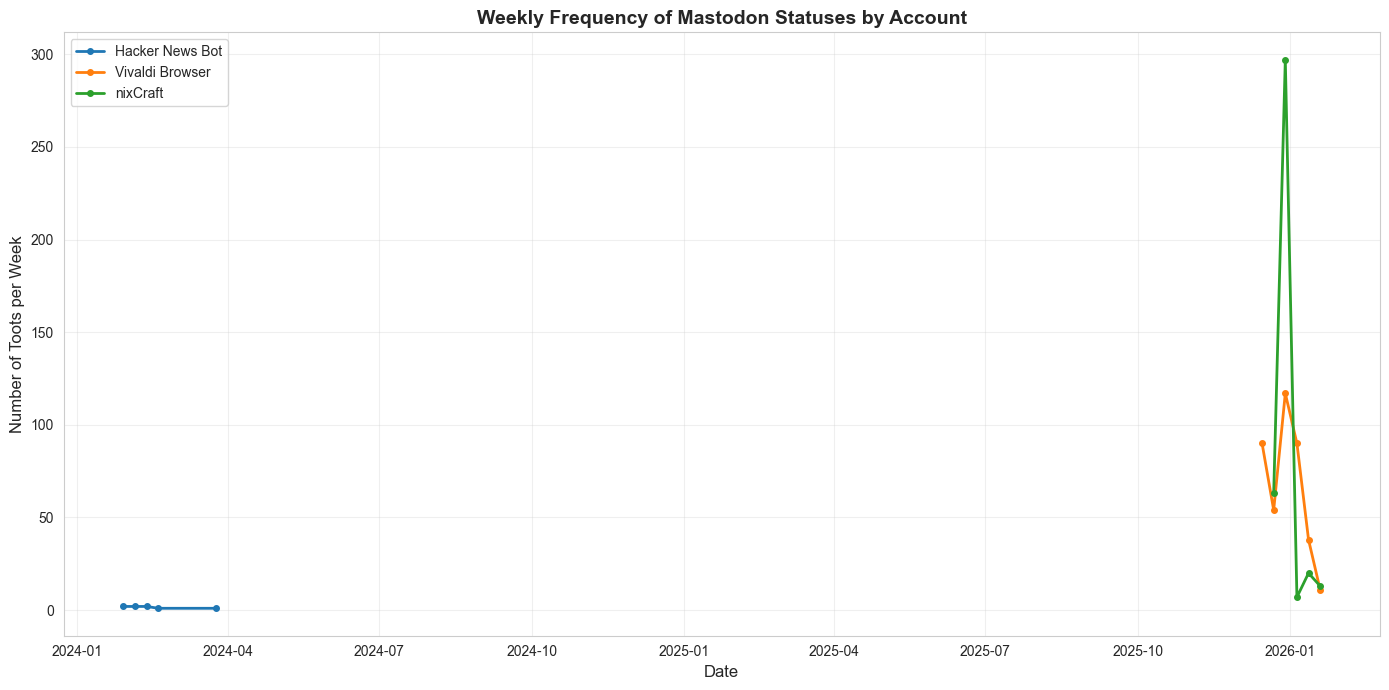

In [107]:
# Convert created_at to datetime and extract week
df_timelines['created_at'] = pd.to_datetime(df_timelines['created_at'])
df_timelines['week'] = df_timelines['created_at'].dt.to_period('W').dt.to_timestamp()

# Aggregate by user and week
weekly_counts = (df_timelines
                 .groupby(['user', 'week'])
                 .size()
                 .reset_index(name='toot_count'))

# Create visualization
plt.figure(figsize=(14, 7), dpi=100)
sns.set_style("whitegrid")

for user in weekly_counts['user'].unique():
    user_data = weekly_counts[weekly_counts['user'] == user]
    plt.plot(user_data['week'], user_data['toot_count'], 
             marker='o', label=user, linewidth=2, markersize=4)

plt.title('Weekly Frequency of Mastodon Statuses by Account', 
          fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Toots per Week', fontsize=12)
plt.legend(loc='best', frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Additional Analysis Ideas

Here are some additional analyses you can perform on the collected Mastodon data:

- **Engagement**: Analyze average engagement (favorites and reblogs) by account to understand which types of content resonate most with audiences. Group by user and calculate mean engagement rates to compare performance across accounts.

- **Top posts**: Identify the most popular posts by sorting by favorites or reblogs count. This can reveal what types of content generate the most engagement and help identify viral posts or trending topics.

- **Posting time**: Examine posting behavior by hour of day or day of week to identify optimal posting times. Aggregate by temporal features to understand when accounts are most active and whether there are patterns related to time zones or audience activity.

- **Language analysis**: Analyze the distribution of languages in your collected toots to understand the multilingual nature of the Fediverse.

- **Content analysis**: Use text analysis techniques on the `clean_content` column to identify common themes, sentiment, or topics discussed by different accounts.

#### Extra: Creating a Reusable Utility Module

Throughout this notebook, we've written several useful functions for collecting and processing Mastodon data. Instead of copying this code every time we start a new project, it's much better to organize these functions into a **utility module** that we can import and reuse.

By creating a `mastodon_utils.py` file, we gain several benefits:
- **Reusability**: Import the same functions across multiple notebooks
- **Maintainability**: Fix bugs or improve functions in one place
- **Cleanliness**: Keep notebooks focused on analysis, not implementation details

Let's explore the main functions we should include in our utility module.

##### 1. Data Collection Functions

The most important utilities handle pagination automatically, so we don't have to write the same loop every time:

**`fetch_hashtag_toots(mastodon, hashtag, max_toots=200, delay=0.5, verbose=True)`**
- Fetches toots by hashtag with automatic pagination
- Handles the `fetch_next()` pattern correctly (reassigning the timeline variable)
- Adds rate limiting delay to avoid network errors
- Returns a clean DataFrame

**`fetch_account_toots(mastodon, account_id, max_toots=400, delay=0.5, verbose=True)`**
- Fetches toots from a specific user account
- Similar pagination pattern as hashtag search
- Useful for analyzing individual accounts or comparing multiple users

##### 2. Data Cleaning Functions

These functions clean and standardize the raw API data:

**`clean_html(html_text)`**
- Removes HTML tags from toot content using BeautifulSoup
- Converts `<p>Hello <strong>world</strong>!</p>` → `Hello world!`

**`add_clean_content(df)`**
- Applies HTML cleaning to the entire DataFrame
- Creates a new `clean_content` column with plain text

**`filter_by_language(df, language='en', verbose=True)`**
- Filters toots by language code (e.g., 'en', 'es', 'fr')
- Removes None values first, then filters
- Prints statistics about how many toots remain

**`select_columns(df, columns=['text', 'created_at'], rename_content=True)`**
- Selects specific columns for analysis
- Optionally renames 'clean_content' to 'text' for convenience
- Keeps DataFrames focused on what you need

##### 3. Data Analysis Functions

These functions help understand the collected data:

**`add_instance_info(df, mastodon_api_base_url)`**
- Extracts instance information from account data
- Shows which Mastodon servers the toots come from
- Useful for understanding the federated nature of Mastodon

**`print_data_quality_report(df)`**
- Generates a comprehensive data quality report
- Shows: total toots, unique IDs, retoots/boosts, language distribution, instance distribution
- Helps validate that data collection worked correctly

##### Example Usage

Once you've created the utility file, using it in a notebook is simple:

```python
# Import the functions you need
from mastodon_utils import (
    fetch_hashtag_toots, 
    add_clean_content, 
    filter_by_language,
    select_columns,
    print_data_quality_report
)

# Collect data (automatically handles pagination)
df = fetch_hashtag_toots(mastodon, "photography", max_toots=200)

# Clean and filter
df = add_clean_content(df)
df = filter_by_language(df, language='en')
df = select_columns(df, columns=['text', 'created_at'])

# Check quality
print_data_quality_report(df)
```

This reduces dozens of lines of code to just a few simple function calls, making your notebooks much cleaner and easier to read!

##### Creating Your Own Utility Module

To create your own `mastodon_utils.py` file:

1. Create a new Python file in the same directory as your notebook
2. Copy the function definitions (see the example `mastodon_utils.py` in this directory if available)
3. Import the module in your notebook: `from mastodon_utils import ...`
4. Use the functions as shown above

**Important**: The utility file must be in the same directory as your notebook, or you need to add it to your Python path.

**Best Practice**: When building your own projects, always consider creating utility modules for repetitive tasks. This makes your code more maintainable and professional!

Check the `mastodon_utils.py` file in this directory for a complete implementation with all functions documented!

#### Bluesky API

Bluesky is a decentralized social network built on the **AT Protocol** (Authenticated Transfer Protocol). Unlike traditional social media platforms, Bluesky operates as a federated network where users can connect across different servers while maintaining a unified experience.

To collect data from Bluesky, we'll use the `atproto` Python library, which provides a clean interface to the AT Protocol API. This library allows us to search for posts, retrieve user profiles, analyze follower networks, and collect historical timelines.

**Important Authentication Note**: Bluesky uses **app passwords** for API access. You must create a separate app password (not your main account password) in your Bluesky settings. This is a security feature that allows you to revoke API access without changing your main password.

**Resources:**
- AT Protocol Documentation: [atproto.com](https://atproto.com/)
- atproto Python Library: [GitHub](https://github.com/MarshalX/atproto)

In [108]:
# Install atproto if needed
# Uncomment the following line if you need to install:
# !pip install atproto

from atproto import Client
from datetime import datetime, timezone
import time

print("atproto library is ready!")

atproto library is ready!


##### Authentication with App Passwords

Bluesky requires **app passwords** for API authentication. This is a security best practice that separates API access from your main account credentials.

**Steps to create an app password:**
1. Go to your Bluesky settings
2. Navigate to **Privacy and Security** → **App Passwords**
3. Click **"Add App Password"**
4. Give it a descriptive name (e.g., "SMWA26")
5. Copy the generated password immediately (you won't see it again!)
6. Store it securely in your `bsky_config.py` file

**Why use app passwords?**
- **Security**: Your main password stays protected
- **Revocability**: You can revoke API access without changing your main password
- **Granularity**: Different apps can have different passwords

**Critical Warning**: Never reuse the same client object for multiple authentication calls. Creating too many sessions will trigger rate limiting and block your access for 24 hours. Always reuse the authenticated client throughout your session.

In [109]:
# Initialize Bluesky client
# Load credentials from config file
try:
    from bsky_config import BLUESKY_USERNAME, BLUESKY_APP_PASSWORD
    
    # Create client and authenticate ONCE
    client = Client()
    client.login(BLUESKY_USERNAME, BLUESKY_APP_PASSWORD)
    
    print("✓ Connected to Bluesky successfully")
    print(f"  Username: {BLUESKY_USERNAME}")
    print("\n⚠ Important: Reuse this 'client' object for all API calls!")
    print("  Do NOT call client.login() again - it will count as a new session")
    
except ImportError:
    print("⚠ config.py not found!")
    print("\nTo create your config.py file:")
    print("1. Go to Bluesky Settings → App Passwords")
    print("2. Create a new app password (NOT your main password!)")
    print("3. Copy the generated password")
    print("4. Create a file named 'config.py' with:")
    print("\n   BLUESKY_USERNAME = 'your_handle.bsky.social'")
    print("   BLUESKY_APP_PASSWORD = 'your_app_password_here'")
    print("\n⚠ The cells below will not work until you set up authentication!")
    
    client = None

# Alternative: Uncomment and fill in your credentials directly (less secure)
# client = Client()
# client.login('your_handle.bsky.social', 'your_app_password')

✓ Connected to Bluesky successfully
  Username: n-marckx.bsky.social

⚠ Important: Reuse this 'client' object for all API calls!
  Do NOT call client.login() again - it will count as a new session


##### Searching for Posts

Let's search for posts mentioning "Trump" to demonstrate how to collect and process Bluesky data. The search function returns a collection of posts with rich metadata including engagement metrics, author information, and post content.

In [115]:
# Search for posts mentioning "Trump"
# Note: The limit parameter is capped at 100 posts per request
if client is None:
    print("❌ Please authenticate first!")
else:
    search_results = client.app.bsky.feed.search_posts({'q': 'Trump', 'limit': 100})
    posts = search_results.posts
    
    print(f"✓ Retrieved {len(posts)} posts")
    
    # To get MORE than 100 posts, use pagination with the 'cursor' parameter
    # The API returns a cursor that points to the next page of results
    if hasattr(search_results, 'cursor') and search_results.cursor:
        print(f"✓ Cursor available for pagination: {search_results.cursor[:50]}...")

✓ Retrieved 96 posts
✓ Cursor available for pagination: 100...


##### Pagination: Getting More Than 100 Posts

The Bluesky API limits each request to 100 posts, but returns a **cursor** that allows you to fetch the next page of results. To collect more posts, you need to make multiple requests using pagination:

**How pagination works:**
1. Make initial request with `limit=100`
2. Check if response has a `cursor` field
3. Make next request with same parameters + `cursor` from previous response
4. Repeat until no more cursor (or desired number of posts reached)

Here's an example of collecting 300 posts using pagination:

In [116]:
# Example: Collect 300 posts using pagination
if client is None:
    print("❌ Please authenticate first!")
else:
    all_posts = []
    cursor = None
    max_posts = 300
    
    while len(all_posts) < max_posts:
        # Make request with cursor (None for first request)
        params = {'q': 'Trump', 'limit': 100}
        if cursor:
            params['cursor'] = cursor
            
        search_results = client.app.bsky.feed.search_posts(params)
        all_posts.extend(search_results.posts)
        
        print(f"✓ Fetched {len(search_results.posts)} posts (total: {len(all_posts)})")
        
        # Check if there's a next page
        if hasattr(search_results, 'cursor') and search_results.cursor:
            cursor = search_results.cursor
        else:
            print("✓ No more posts available")
            break
            
    print(f"\n✓ Total posts collected: {len(all_posts)}")

✓ Fetched 97 posts (total: 97)
✓ Fetched 97 posts (total: 194)
✓ Fetched 98 posts (total: 292)
✓ Fetched 99 posts (total: 391)

✓ Total posts collected: 391


##### Converting Posts to DataFrame

The API returns nested JSON objects. We'll extract the key fields and convert them into a clean pandas DataFrame for analysis:

In [117]:
# Extract relevant fields from posts into a structured format
posts_data = []

for post in posts:
    posts_data.append({
        'cid': post.cid,
        'uri': post.uri,
        'author_handle': post.author.handle,
        'author_display_name': post.author.display_name,
        'text': post.record.text,
        'created_at': post.record.created_at,
        'reply_count': post.reply_count or 0,
        'repost_count': post.repost_count or 0,
        'like_count': post.like_count or 0,
        'quote_count': post.quote_count or 0
    })

df_posts = pd.DataFrame(posts_data)
print(f"✓ Converted to DataFrame: {df_posts.shape}")
print(f"\nColumns: {list(df_posts.columns)}")

✓ Converted to DataFrame: (96, 10)

Columns: ['cid', 'uri', 'author_handle', 'author_display_name', 'text', 'created_at', 'reply_count', 'repost_count', 'like_count', 'quote_count']


##### Preview Sample Posts

Let's look at the actual content of some randomly selected posts:

In [118]:
# Display 3 random post texts
sample_posts = df_posts['text'].sample(n=3, random_state=42)

for i, text in enumerate(sample_posts, 1):
    print(f"Post {i}:")
    print(text[:200] + "..." if len(text) > 200 else text)
    print()

Post 1:
www.notus.org/trump-white-...

F U Creepy Liar-in-Chief #DonaldTrump and #WhiteHouse 8647

Can no longer trust any of them
Plan ahead, Slow them down,  Help and lookout for each other
Nothing worst th...

Post 2:
Trump or the Constitution, american democracy can't have both.

Post 3:
www.newsweek.com/mary-trump-r...



##### Searching for User Profiles

Now let's search for a specific user account and retrieve their profile information, including follower counts and bio:

In [119]:
# Search for Prof. Dirk Van den Poel's account
if client:
    search_actors = client.app.bsky.actor.search_actors({'q': 'dirk van den poel', 'limit': 5})
    
    if search_actors.actors:
        # Get the best match (first result)
        dvdp_actor = search_actors.actors[0]
        print(f"Found: {dvdp_actor.display_name} (@{dvdp_actor.handle})")
        
        # Get full profile information
        dvdp_profile = client.app.bsky.actor.get_profile({'actor': dvdp_actor.handle})
        
        print(f"\nProfile Information:")
        print(f"  Display Name: {dvdp_profile.display_name}")
        print(f"  Handle: {dvdp_profile.handle}")
        print(f"  Followers: {dvdp_profile.followers_count}")
        print(f"  Following: {dvdp_profile.follows_count}")
        print(f"  Posts: {dvdp_profile.posts_count}")
    else:
        print("Account not found")

Found: Dirk Van den Poel  (@dirkvandenpoel.bsky.social)

Profile Information:
  Display Name: Dirk Van den Poel 
  Handle: dirkvandenpoel.bsky.social
  Followers: 380
  Following: 427
  Posts: 69


##### Retrieving Followers

Let's retrieve the followers list for the account we found. Note that privacy settings may limit how many followers can be retrieved:

In [120]:
# Retrieve followers (limited by API and privacy settings)
if client and 'dvdp_profile' in locals():
    followers_response = client.app.bsky.graph.get_followers({
        'actor': dvdp_profile.handle,
        'limit': min(100, dvdp_profile.followers_count)  # Limit to 100 for demo
    })
    
    followers_data = []
    for f in followers_response.followers:
        # Handle None values properly
        desc = getattr(f, 'description', None)
        desc_text = desc[:100] if desc else ''
        
        followers_data.append({
            'handle': f.handle,
            'display_name': f.display_name,
            'description': desc_text
        })
    
    df_followers = pd.DataFrame(followers_data)
    print(f"✓ Retrieved {len(df_followers)} followers")
    print("\nNote: Due to privacy settings, not all followers may be accessible via API")

✓ Retrieved 72 followers

Note: Due to privacy settings, not all followers may be accessible via API


##### Collecting Posts from Multiple News Accounts

Now let's analyze posting behavior from several popular news organizations. We'll search for accounts, retrieve their recent posts, and compare their activity patterns:

In [121]:
# Search for popular news accounts
if client:
    news_accounts = {
        "Economist": "economist",
        "FT": "financialtimes",
        "CNN": "cnn"
    }
    
    # Find the actual handles
    account_handles = {}
    for name, search_term in news_accounts.items():
        try:
            search = client.app.bsky.actor.search_actors({'q': search_term, 'limit': 1})
            if search.actors:
                account_handles[name] = search.actors[0].handle
                print(f"✓ Found {name}: @{search.actors[0].handle}")
        except Exception as e:
            print(f"✗ Could not find {name}: {e}")
    
    print(f"\n✓ Found {len(account_handles)} accounts")

✓ Found Economist: @justinwolfers.bsky.social
✓ Found FT: @financialtimes.com
✓ Found CNN: @jaketapper.bsky.social

✓ Found 3 accounts


##### Retrieving Author Feeds

For each news account, we'll retrieve up to 1000 recent posts. This may take a minute due to API pagination:

In [122]:
# Retrieve posts from each account (with pagination)
all_statuses = []

if client and 'account_handles' in locals():
    for name, handle in account_handles.items():
        print(f"Retrieving posts from {name}...", end=" ")
        
        try:
            # Get author feed with pagination
            cursor = None
            posts_collected = []
            
            while len(posts_collected) < 1000:
                params = {'actor': handle, 'limit': 100}
                if cursor:
                    params['cursor'] = cursor
                
                feed = client.app.bsky.feed.get_author_feed(params)
                
                if not feed.feed:
                    break
                
                posts_collected.extend(feed.feed)
                cursor = feed.cursor
                
                if not cursor:
                    break
                
                time.sleep(0.3)  # Rate limiting
            
            # Extract data from posts
            for post_view in posts_collected[:1000]:
                all_statuses.append({
                    'user': name,
                    'author_handle': post_view.post.author.handle,
                    'text': post_view.post.record.text,
                    'created_at': post_view.post.record.created_at,
                    'reply_count': post_view.post.reply_count or 0,
                    'repost_count': post_view.post.repost_count or 0,
                    'like_count': post_view.post.like_count or 0,
                    'quote_count': post_view.post.quote_count or 0
                })
            
            print(f"✓ {len([s for s in all_statuses if s['user'] == name])} posts")
            
        except Exception as e:
            print(f"✗ Error: {e}")
    
    # Convert to DataFrame
    df_timelines = pd.DataFrame(all_statuses)
    print(f"\n✓ Total posts collected: {len(df_timelines)}")

Retrieving posts from Economist... ✓ 1000 posts
Retrieving posts from FT... ✓ 1000 posts
Retrieving posts from CNN... ✓ 1000 posts

✓ Total posts collected: 3000


##### Processing Timestamps

Convert the timestamp strings to proper datetime objects for time-based analysis:

In [123]:
# Convert created_at to datetime and extract week
if 'df_timelines' in locals() and len(df_timelines) > 0:
    # Use format='ISO8601' to handle varying timestamp formats
    df_timelines['created_at'] = pd.to_datetime(df_timelines['created_at'], format='ISO8601')
    df_timelines['week'] = df_timelines['created_at'].dt.to_period('W').dt.to_timestamp()
    
    print(f"✓ Date range: {df_timelines['created_at'].min()} to {df_timelines['created_at'].max()}")

✓ Date range: 2023-09-24 15:08:07.887000+00:00 to 2026-01-23 19:23:26.086775+00:00


/var/folders/ft/tnz7yjv95wngxpfm4n16d0ch0000gn/T/ipykernel_4047/2573645894.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_timelines['week'] = df_timelines['created_at'].dt.to_period('W').dt.to_timestamp()


##### Visualizing Posting Frequency Over Time

Let's create a time series visualization showing the weekly posting frequency for each news account. This helps us understand their content strategies and activity patterns:

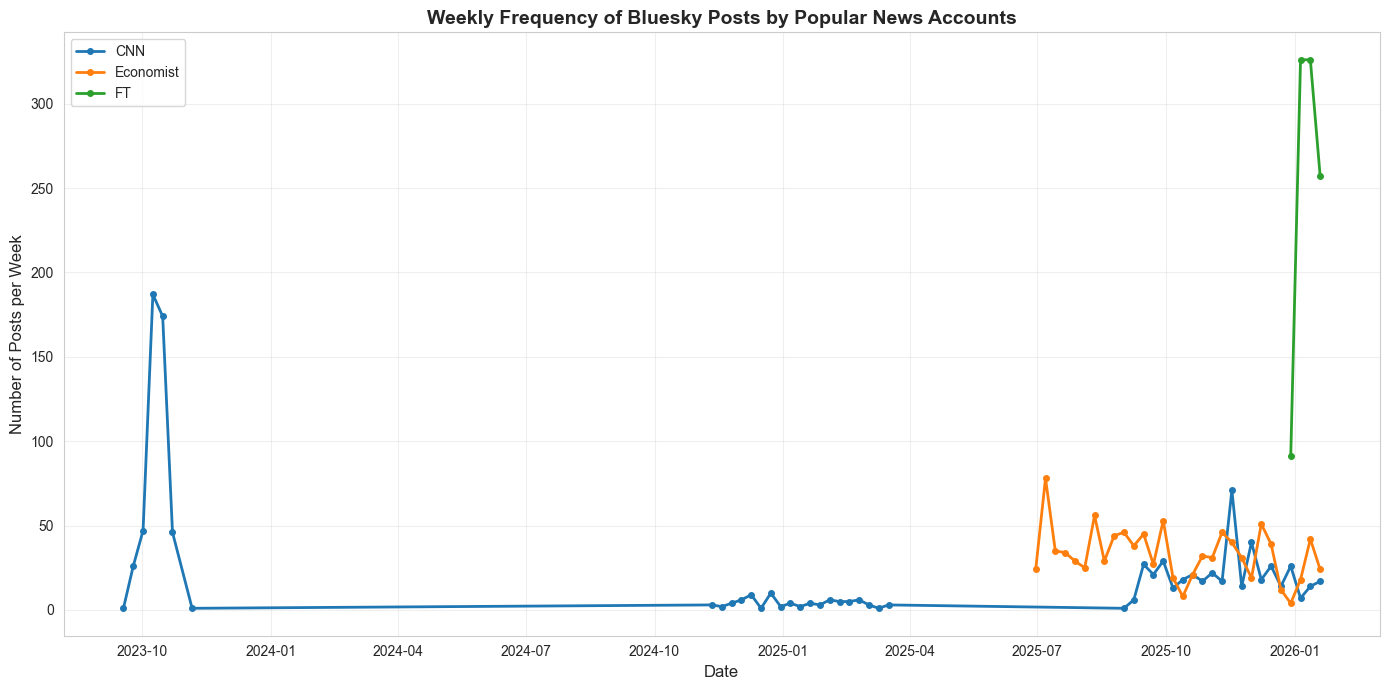

In [124]:
# Aggregate by user and week
if 'df_timelines' in locals() and len(df_timelines) > 0:
    weekly_counts = (df_timelines
                     .groupby(['user', 'week'])
                     .size()
                     .reset_index(name='post_count'))
    
    # Create visualization
    plt.figure(figsize=(14, 7), dpi=100)
    sns.set_style("whitegrid")
    
    for user in weekly_counts['user'].unique():
        user_data = weekly_counts[weekly_counts['user'] == user]
        plt.plot(user_data['week'], user_data['post_count'], 
                 marker='o', label=user, linewidth=2, markersize=4)
    
    plt.title('Weekly Frequency of Bluesky Posts by Popular News Accounts', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Number of Posts per Week', fontsize=12)
    plt.legend(loc='best', frameon=True)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No timeline data available for visualization")

### Social Media: Centralized Platforms

While open platforms like Mastodon and Bluesky provide straightforward API access, many popular services have **more restricted APIs** that make data collection more challenging. This section provides inspiration and starting points for exploring these platforms.

**Why "More Restricted" Platforms Are Different:**

Unlike the open APIs we've explored, more restricted platforms typically:
- **Require approval**: Lengthy application processes for API access
- **Have strict limitations**: Rate limits, data restrictions, or prohibitive costs
- **Change frequently**: APIs deprecated or access revoked without notice
- **Prohibit scraping**: Terms of Service explicitly forbid web scraping
- **Use anti-bot measures**: CAPTCHAs, IP blocking, JavaScript-heavy pages

**Important**: Always respect platform Terms of Service and legal restrictions. Academic research may have exceptions, but verify before collecting data.

#### Example 1: Reddit - PRAW Library

**Reddit** is a social news platform organized into topic-based communities (subreddits). While Reddit offers an API, access has become increasingly restricted.

**Challenges:**
- Requires OAuth authentication, which has become more difficult to obtain (e.g., pure academic research would still work if you are an affiliated researcher)
- Rate limits (60 requests/minute)
- API changes frequently break existing code
- Many features deprecated or paywalled

**Python Library:**
```python
# PRAW (Python Reddit API Wrapper)
import praw

reddit = praw.Reddit(
    client_id='YOUR_CLIENT_ID',
    client_secret='YOUR_SECRET',
    user_agent='YOUR_APP_NAME'
)

# Example: Get subreddit posts
subreddit = reddit.subreddit('datascience')
for post in subreddit.hot(limit=10):
    print(post.title, post.score)
```

**Resources:**
- PRAW Documentation: [praw.readthedocs.io](https://praw.readthedocs.io/)
- Reddit API: [reddit.com/dev/api](https://www.reddit.com/dev/api/)

#### Example 2: Steam - Game Data and Reviews

**Steam** is a video game platform with extensive user reviews and game metadata. Valve provides API access.

**Available Data:**
- Game metadata (name, genre, price, etc.)
- User reviews and ratings
- Player statistics
- Store page information

**Python Libraries:**
```python
# Steam Web API (official)
import requests

# Get game details
app_id = 730  # Counter-Strike: Global Offensive
url = f"http://store.steampowered.com/api/appdetails?appids={app_id}"
response = requests.get(url)
data = response.json()

# Alternative: steamreviews library for review data
# pip install steamreviews
from steamreviews import download_reviews_for_app_id

reviews = download_reviews_for_app_id(app_id, num_reviews=100)
```

**Resources:**
- Steam Web API: [steamcommunity.com/dev](https://steamcommunity.com/dev)
- Steam Spy: [steamspy.com](https://steamspy.com/) (game statistics)
- steamreviews library: [GitHub](https://github.com/woctezuma/steam-reviews)

#### Example 3: Spotify - Music and Podcast Data

**Spotify** provides a comprehensive API for music metadata, playlists, and user listening data (with authorization).

**Available Data:**
- Track metadata (artist, album, genre, audio features)
- Playlist information
- User listening history (with OAuth)
- Podcast episodes and shows

**Python Library:**
```python
# Spotipy (official Python wrapper)
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

# Initialize
sp = spotipy.Spotify(auth_manager=SpotifyClientCredentials(
    client_id='YOUR_CLIENT_ID',
    client_secret='YOUR_SECRET'
))

# Search for tracks
results = sp.search(q='artist:Radiohead', type='track', limit=10)
for track in results['tracks']['items']:
    print(track['name'], track['popularity'])

# Get audio features (tempo, energy, etc.)
audio_features = sp.audio_features(['spotify:track:TRACK_ID'])
```

**Resources:**
- Spotify Web API: [developer.spotify.com/documentation/web-api](https://developer.spotify.com/documentation/web-api/)
- Spotipy Documentation: [spotipy.readthedocs.io](https://spotipy.readthedocs.io/)

**Use Cases:**
- Music recommendation systems
- Genre classification
- Mood analysis from audio features
- Podcast trend analysis